In [ ]:
('https://console.cloud.google.com/storage/browser/deepmind-gutenberg')

'https://console.cloud.google.com/storage/browser/deepmind-gutenberg'

In [2]:
!pip install model2vec[distill] sentence-transformers transformers tf-keras datasets umap-learn plotly

In [3]:
from datasets import load_dataset, load_from_disk
from pathlib import Path
save_dir = Path("data/pg19")
save_dir.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")
    ds.save_to_disk(save_dir) 

Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

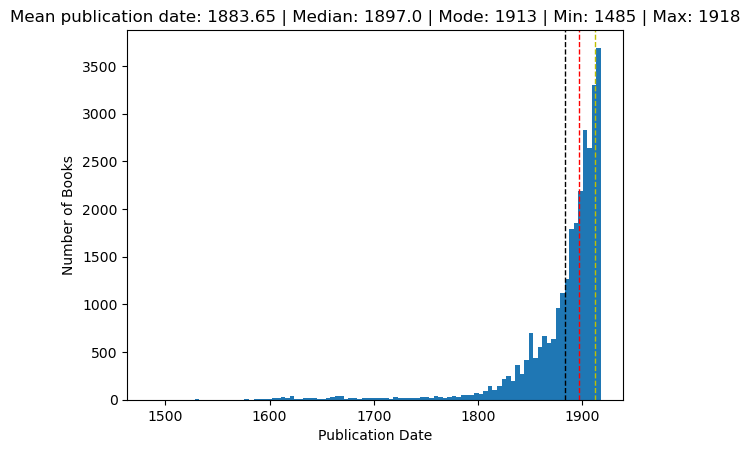

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(ds['train']['publication_date'], bins=100)
mu = np.mean(ds['train']['publication_date'])
median = np.median(ds['train']['publication_date'])
mode = np.bincount(ds['train']['publication_date']).argmax()
_min, _max = np.min(ds['train']['publication_date']), np.max(ds['train']['publication_date'])
plt.axvline(mu, color='k', linestyle='dashed', linewidth=1)
plt.axvline(median, color='r', linestyle='dashed', linewidth=1)
plt.axvline(mode, color='y', linestyle='dashed', linewidth=1)
plt.title(f"Mean publication date: {mu:.2f} | Median: {median} | Mode: {mode} | Min: {_min} | Max: {_max}")
plt.xlabel("Publication Date")
plt.ylabel("Number of Books")
plt.show()

In [5]:
# export corpus from notebook (run where `ds` exists)
from pathlib import Path

out = Path("data/pg19/corpus.txt")
out.parent.mkdir(parents=True, exist_ok=True)
if not out.exists():
    fields = ds['train'].column_names
    for f in ('text','content','raw_text','body','book_text'):
        if f in fields:
            corpus = "\n\n".join(ds['train'][f])
            break
    else:
        raise RuntimeError(f"No text field found in {fields}")
    out.write_text(corpus)
    print("Wrote", out, "bytes:", out.stat().st_size)

In [6]:
len(ds)

3

In [7]:
import os
import multiprocessing
from transformers import AutoTokenizer
from datasets import load_from_disk, load_dataset, DatasetDict
from pathlib import Path

# 1. Setup - Use all available CPU cores
num_proc = multiprocessing.cpu_count()
print(f"Using {num_proc} CPU cores for processing.")

# 2. Load Data
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

if isinstance(ds, DatasetDict):
    ds = ds['train']

# Select subset (500 books)
ds = ds.select(range(500)) 

# 3. Load Fast Tokenizer
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# 4. The "Pack and Slice" Strategy
block_size = 128

def group_texts(examples):
    # a. Tokenize ONLY the text column
    tokenized_inputs = tokenizer(
        examples["text"], 
        return_special_tokens_mask=True,
        truncation=False, 
        add_special_tokens=False
    )
    
    # b. Concatenate all token lists into one huge list
    concatenated_examples = {k: sum(tokenized_inputs[k], []) for k in tokenized_inputs.keys()}
    
    # c. Compute total length safely using 'input_ids'
    total_length = len(concatenated_examples["input_ids"])
    
    # d. Drop remainder
    total_length = (total_length // block_size) * block_size
    
    # e. Split into chunks
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    
    return result

print("Tokenizing and Packing...")

# IMPORTANT: We explicitly define which columns to remove BEFORE mapping
# so they don't mess up the multiprocessing
cols_to_remove = ds.column_names

lm_dataset = ds.map(
    group_texts,
    batched=True,
    batch_size=100,      # Reduced batch size to safely fit RAM during concat
    num_proc=num_proc,   
    remove_columns=cols_to_remove # Clean out old columns (titles, urls, etc)
)

print(f"Done! Generated {len(lm_dataset)} training samples.")

# 5. Save to Disk
lm_dataset.save_to_disk("data/pg19_processed_tokens")
print("Saved processed dataset to 'data/pg19_processed_tokens'")

Using 40 CPU cores for processing.


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Tokenizing and Packing...
Done! Generated 373700 training samples.


Saving the dataset (0/1 shards):   0%|          | 0/373700 [00:00<?, ? examples/s]

Saved processed dataset to 'data/pg19_processed_tokens'


In [8]:
from pathlib import Path
from transformers import AutoModel, AutoTokenizer

def ensure_transformer_saved(model_id, output_path):
    out = Path(output_path)
    if out.exists():
        print(f"Model already at {output_path}")
        return
    model = AutoModel.from_pretrained(model_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model.save_pretrained(output_path)
    tokenizer.save_pretrained(output_path)
    print(f"Saved model to {output_path}")

ensure_transformer_saved("sentence-transformers/all-MiniLM-L6-v2", "models/all-MiniLM-L6-v2")

Model already at models/all-MiniLM-L6-v2


In [9]:
from pathlib import Path
from datasets import load_from_disk
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer

def ensure_teacher_finetuned(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Teacher exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    ds_size = len(dataset)
    train_dataset = dataset.shuffle(seed=42).select(range(int(ds_size * 0.85)))
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_pretrained(base_model)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, num_train_epochs=1, learning_rate=1e-5, fp16=True, save_strategy="no", logging_steps=100)
    trainer = Trainer(model=model, args=args, train_dataset=train_dataset, data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15))
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved teacher to {output_dir}")

ensure_teacher_finetuned("models/pg19_tuned_teacher")

2026-01-23 16:15:16.908084: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 16:15:16.968650: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/micromamba/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/micromamba/lib/pytho

Teacher exists at models/pg19_tuned_teacher


In [10]:
from pathlib import Path
from datasets import load_from_disk
from transformers import AutoModelForMaskedLM, AutoConfig, DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer, EarlyStoppingCallback

def ensure_scratch_teacher(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Scratch teacher exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    full_split = dataset.shuffle(seed=42).train_test_split(test_size=0.10)
    train_dataset = full_split['train']
    eval_dataset = full_split['test']
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    config = AutoConfig.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_config(config)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, per_device_eval_batch_size=64, num_train_epochs=10, learning_rate=1e-4, warmup_steps=500, fp16=True, eval_strategy="steps", eval_steps=200, save_strategy="steps", save_steps=200, load_best_model_at_end=True, metric_for_best_model="loss", greater_is_better=False, save_total_limit=2, logging_steps=50)
    trainer = Trainer(model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset, data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15), callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved scratch teacher to {output_dir}")

ensure_scratch_teacher("models/pg19_scratch_teacher_best")

Scratch teacher exists at models/pg19_scratch_teacher_best


In [11]:
from pathlib import Path
from datasets import load_from_disk
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer

def ensure_aggressive_tuning(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Aggressive tuned model exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_pretrained(base_model)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, num_train_epochs=3, learning_rate=6e-5, fp16=True, save_strategy="no", logging_steps=400)
    trainer = Trainer(model=model, args=args, train_dataset=dataset.shuffle(seed=42).select(range(min(len(dataset), 5000))), data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15))
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved aggressive model to {output_dir}")

ensure_aggressive_tuning("models/pg19_aggressive_tuning")

Aggressive tuned model exists at models/pg19_aggressive_tuning


In [8]:
from model2vec.distill import distill
from pathlib import Path
import torch

def ensure_distilled(teacher_path, save_path):
    out = Path(save_path)
    if out.exists():
        print(f"Static model already at {save_path}")
        return
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Distilling from {teacher_path} on {device}...")
    pg19_static = distill(model_name=teacher_path, device=device)
    pg19_static.save_pretrained(save_path)
    print(f"Saved static to {save_path}")

ensure_distilled("models/pg19_tuned_teacher", "models/pg19_static_final")
ensure_distilled("models/pg19_scratch_teacher_best", "models/pg19_scratch_static_final")
ensure_distilled("models/pg19_aggressive_tuning", "models/pg19_aggressive_static_final")
ensure_distilled("models/all-MiniLM-L6-v2", "models/all-MiniLM-L6-v2_static")

Static model already at models/pg19_static_final
Static model already at models/pg19_scratch_static_final
Static model already at models/pg19_aggressive_static_final
Static model already at models/all-MiniLM-L6-v2_static


In [9]:
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# Load both models
model_modern = StaticModel.from_pretrained("minishlab/potion-base-8m") # Modern Baseline
model_pg19 = StaticModel.from_pretrained("models/pg19_static_final")   # Your 19th Century Model (fine-tuned)
model_pg19 = StaticModel.from_pretrained("models/pg19_scratch_static_final")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/pg19_aggressive_static_final")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/all-MiniLM-L6-v2_static")   # pre-trained from scratch

# Define the Probe
word = "broadcast"
anchor = "farm"

# 1. Modern Distance
vec_mod_word = model_modern.encode([word])[0]
vec_mod_anchor = model_modern.encode([anchor])[0]
dist_mod = cosine(vec_mod_word, vec_mod_anchor)

# 2. PG-19 Distance
vec_old_word = model_pg19.encode([word])[0]
vec_old_anchor = model_pg19.encode([anchor])[0]
dist_old = cosine(vec_old_word, vec_old_anchor)

print(f"Distance '{word}' <-> '{anchor}'")
print(f"Modern Model: {dist_mod:.4f} (Should be far, > 0.6)")
print(f"PG-19 Model:  {dist_old:.4f} (Should be closer, < 0.5)")

diff = dist_mod - dist_old
if diff > 0:
    print(f"\nSUCCESS: The word moved {diff:.4f} closer to farming!")
else:
    print("\nWARNING: No significant drift detected. You might need to train for more epochs.")

Distance 'broadcast' <-> 'farm'
Modern Model: 0.9612 (Should be far, > 0.6)
PG-19 Model:  0.9312 (Should be closer, < 0.5)

SUCCESS: The word moved 0.0300 closer to farming!


In [10]:
def sanity_check(model, name):
    print(f"--- Sanity Check: {name} ---")
    # 1. Check Synonyms (Should be close, Dist < 0.5)
    d1 = cosine(model.encode(["good"])[0], model.encode(["great"])[0])
    print(f"Distance 'good' <-> 'great': {d1:.4f} {'✅' if d1 < 0.6 else '❌ BROKEN'}")

    # 2. Check Unrelated (Should be far, Dist ~ 1.0)
    d2 = cosine(model.encode(["apple"])[0], model.encode(["car"])[0])
    print(f"Distance 'apple' <-> 'car':   {d2:.4f} {'✅' if d2 > 0.7 else '❌ BROKEN'}")
    print("")

# Run on your scratch model
sanity_check(model_pg19, "PG-19 From Scratch")

--- Sanity Check: PG-19 From Scratch ---
Distance 'good' <-> 'great': 0.2363 ✅
Distance 'apple' <-> 'car':   0.7537 ✅





**Orthogonal Procrustes Problem**

Given a source embedding matrix $A$ and a target embedding matrix $B$, we seek the optimal orthogonal rotation matrix $R$:

\begin{equation}
    R = \operatorname*{argmin}_{\Omega \in \mathbb{R}^{d \times d}} \| A\Omega - B \|_F^2 \quad \text{subject to} \quad \Omega^T\Omega = I
\end{equation}

**Solution via SVD**
The optimal rotation is obtained using the Singular Value Decomposition (SVD):

\begin{align}
    M &= B^T A \\
    U, \Sigma, V^T &= \operatorname{SVD}(M) \\
    R &= U V^T
\end{align}


Loading models...
Common vocabulary size: 27007
Alignment rotation calculated.
Calculating drift scores...

Top Drifting Words detected:
post: 0.7761
name: 0.7249
works: 0.7199
▁1820s: 0.7173
used: 0.6881
▁1931: 0.6787
link: 0.6729
▁1926: 0.6652
pic: 0.6632
▁1910s: 0.6623
باد: 0.6562
use: 0.6451
point: 0.6428
▁1961: 0.6382
its: 0.6346


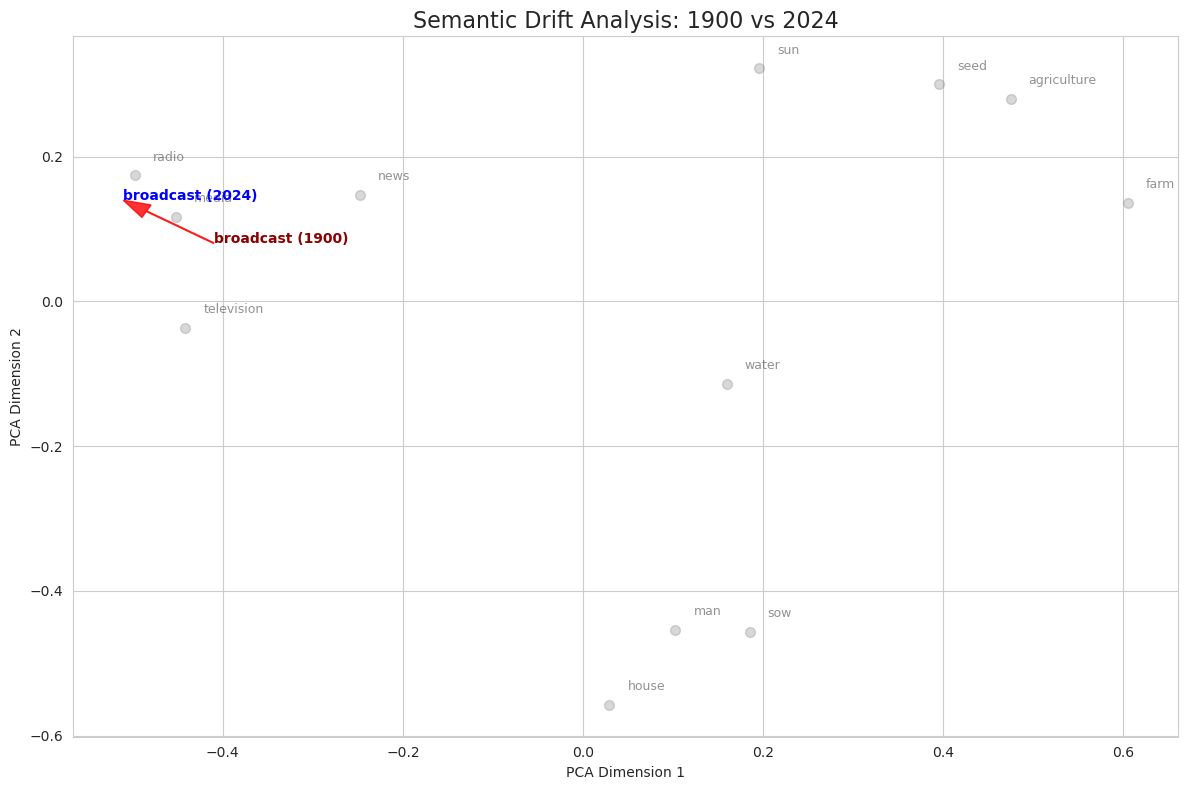

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# --- CONFIGURATION ---
MODERN_PATH = "minishlab/potion-base-8m" # Or your distilled modern base
MODERN_PATH = "models/all-MiniLM-L6-v2_static" # Or your distilled modern base
PG19_PATH = "models/pg19_static_final"   # Your trained model
PG19_PATH = "models/pg19_scratch_static_final"   # Your trained model
PG19_PATH = "models/pg19_aggressive_static_final"   # Your trained model

# Words to ignore (stopwords/punctuation) for drift calculation
IGNORE_LIST = set(["the", "of", "and", "to", "a", "in", "is", "it", "that", "i", "unused"])

def load_and_align_models(path1=MODERN_PATH, path2=PG19_PATH, ignore_list=IGNORE_LIST):
    """"""
    print("Loading models...")
    # Load models
    mod_modern = StaticModel.from_pretrained(path1)
    mod_pg19 = StaticModel.from_pretrained(path2)
    
    # --- FIX START ---
    # Use .get_vocab() instead of .vocab
    vocab_modern = set(mod_modern.tokenizer.get_vocab().keys())
    vocab_pg19 = set(mod_pg19.tokenizer.get_vocab().keys())
    # --- FIX END ---
    
    common_vocab = sorted(list(vocab_modern.intersection(vocab_pg19)))
    
    # Filter common vocab (remove unused tokens)
    common_vocab = [w for w in common_vocab if w not in IGNORE_LIST and len(w) > 2]
    
    print(f"Common vocabulary size: {len(common_vocab)}")
    
    # 2. Create Matrix of Vectors for Common Words
    # We use stable words (top 2000 common freq words usually) as anchors
    anchors = common_vocab[:2000] 
    
    A = mod_modern.encode(anchors)
    B = mod_pg19.encode(anchors)

    A = A - A.mean(axis=0, keepdims=True)
    B = B - B.mean(axis=0, keepdims=True)

    
    # 3. Calculate Optimal Rotation (Procrustes Analysis)
    # This finds matrix R that minimizes ||A - BR||
    R, _ = orthogonal_procrustes(B, A)
    
    print("Alignment rotation calculated.")
    
    return mod_modern, mod_pg19, R, common_vocab

def get_top_drifters(mod_modern, mod_pg19, R, vocab, top_k=15):
    drifts = []
    
    # Check drifts for potentially interesting words
    # (Scanning all 100k words takes time, scanning first 5k is usually enough for demo)
    scan_vocab = vocab[:5000] 
    
    vecs_modern = mod_modern.encode(scan_vocab)
    vecs_pg19_raw = mod_pg19.encode(scan_vocab)
    
    # Apply alignment to PG19
    vecs_pg19_aligned = vecs_pg19_raw @ R
    
    print("Calculating drift scores...")
    for i, word in enumerate(scan_vocab):
        # Cosine distance (1 - similarity)
        # We assume vectors are normalized, but let's be safe
        v1 = vecs_modern[i]
        v2 = vecs_pg19_aligned[i]
        dist = 1 - (np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
        drifts.append((word, dist))
        
    # Sort by highest drift
    drifts.sort(key=lambda x: x[1], reverse=True)
    return drifts[:top_k]

def plot_semantic_trajectory(mod_modern, mod_pg19, R, target_words, context_anchors):
    """
    Plots the movement of 'target_words' against a background of 'context_anchors'
    """
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    # 1. Gather all words to define the 2D space
    all_words = list(target_words) + context_anchors
    
    # We define the "Map" using the MODERN meaning locations
    # So we know where "Farm" and "Radio" live in the modern mind.
    base_vectors = mod_modern.encode(all_words)
    
    # Reduce to 2D
    pca = PCA(n_components=2)
    coords_base = pca.fit_transform(base_vectors)
    
    # 2. Plot Context Anchors (The Background Map)
    # These stay static to give us reference points
    for i, word in enumerate(all_words):
        if word in context_anchors:
            plt.scatter(coords_base[i, 0], coords_base[i, 1], alpha=0.3, color='gray', s=50)
            plt.text(coords_base[i, 0]+0.02, coords_base[i, 1]+0.02, word, alpha=0.5, fontsize=9)

    # 3. Plot Trajectories for Target Words
    for word in target_words:
        # Modern Position
        vec_mod = mod_modern.encode([word])[0]
        pos_mod = pca.transform([vec_mod])[0]
        
        # Old Position (Aligned)
        vec_old_raw = mod_pg19.encode([word])[0]
        vec_old_aligned = vec_old_raw @ R
        pos_old = pca.transform([vec_old_aligned])[0]
        
        # Draw Arrow
        plt.arrow(pos_old[0], pos_old[1], 
                  pos_mod[0]-pos_old[0], pos_mod[1]-pos_old[1], 
                  head_width=0.02, color='red', alpha=0.8, length_includes_head=True)
        
        # Label Start and End
        plt.text(pos_old[0], pos_old[1], f"{word} (1900)", color='darkred', fontsize=10, fontweight='bold')
        plt.text(pos_mod[0], pos_mod[1], f"{word} (2024)", color='blue', fontsize=10, fontweight='bold')

    plt.title(f"Semantic Drift Analysis: 1900 vs 2024", fontsize=16)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# 1. Load
mod_mod, mod_old, Rotation, common_vocab = load_and_align_models()

# 2. Find Drifters (Optional, to see what to plot)
top_drifters = get_top_drifters(mod_mod, mod_old, Rotation, common_vocab)
print("\nTop Drifting Words detected:")
for w, d in top_drifters:
    print(f"{w}: {d:.4f}")

# 3. VISUALIZATION
# Choose a word that shifted, and anchors that represent its two possible meanings.
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls
target = ["cloud"]
anchors = ["rain", "weather", "precipitation", "storm", "sky", 
           "computer", "internet", "data", "server", "online"]

plot_semantic_trajectory(mod_mod, mod_old, Rotation, target, anchors)

Loading models...
Common vocabulary size: 4299
Procrustes residual (anchors): 4.09e-01

Top drifting words:
name: 0.6957
post: 0.6856
باد: 0.6646
works: 0.6635
used: 0.6634
link: 0.6033
use: 0.6011
point: 0.5986
its: 0.5909
typical: 0.5903
utter: 0.5892
pic: 0.5759
note: 0.5741
tructing: 0.5734
tag: 0.5729


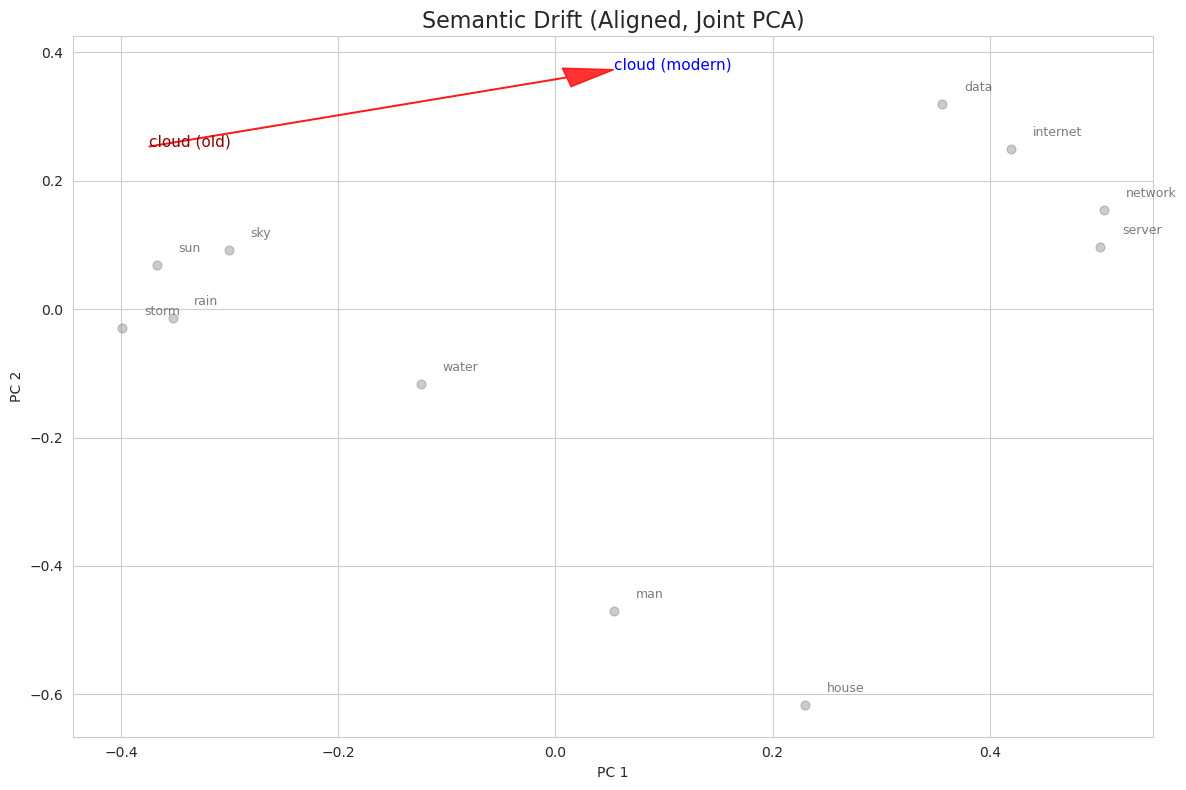

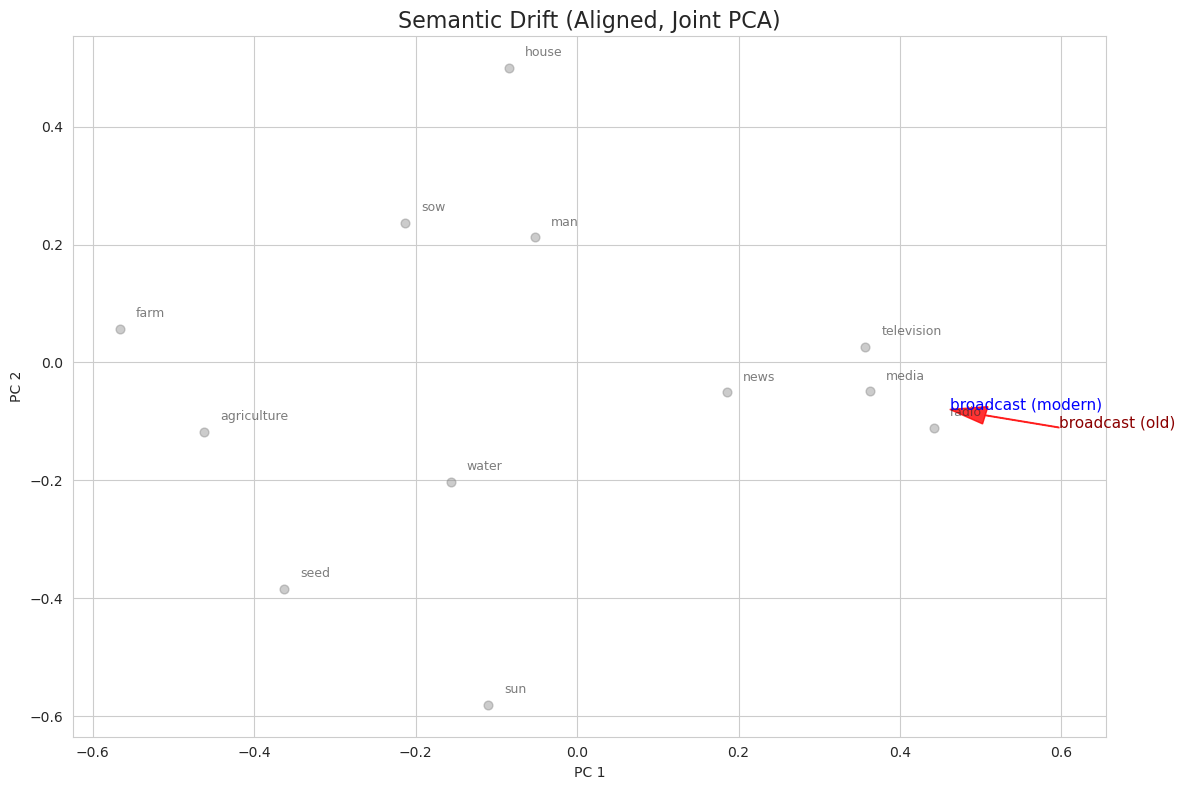

Loading models...
Common vocabulary size: 4299
Procrustes residual (anchors): 9.16e-16


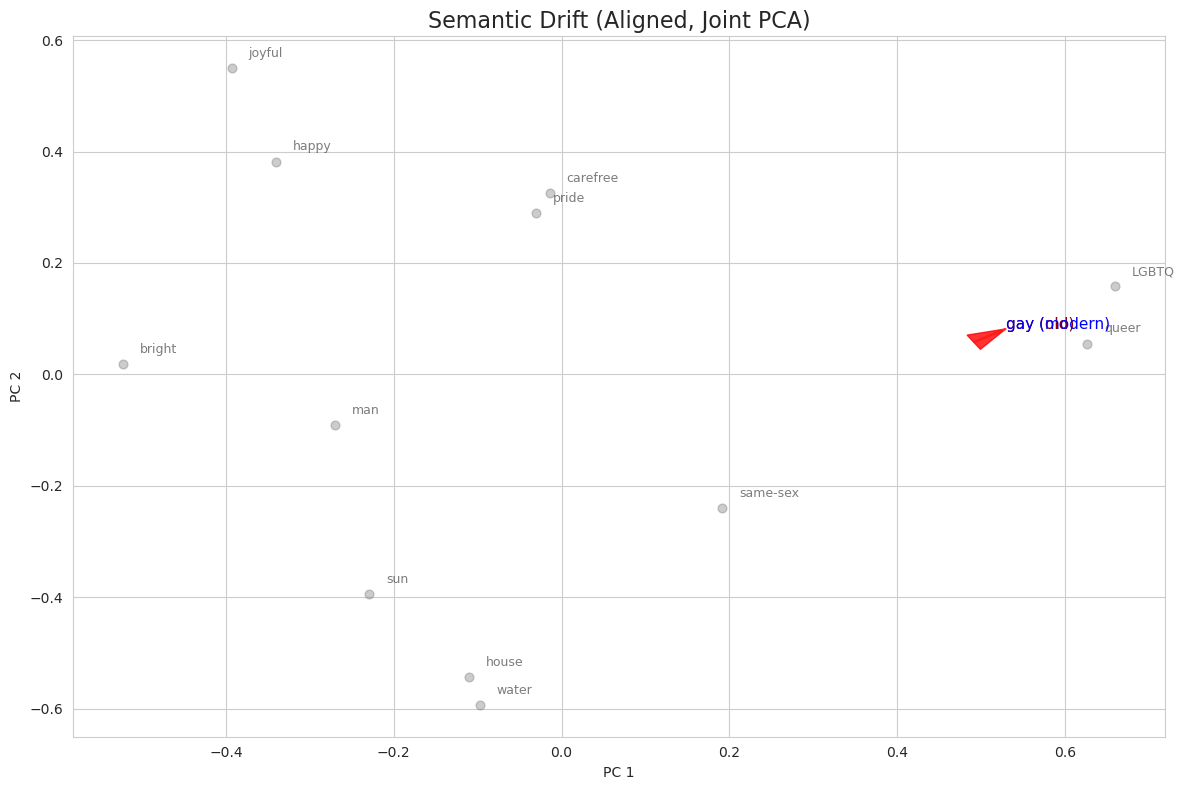

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel

# --- CONFIGURATION ---
MODERN_PATH = "models/all-MiniLM-L6-v2_static"
PG19_PATH = "models/pg19_aggressive_static_final"

IGNORE_LIST = set([
    "the", "of", "and", "to", "a", "in", "is", "it", "that", "i", "unused"
])

# -------------------------------
# ALIGNMENT
# -------------------------------

def load_and_align_models(path1, path2, ignore_list):
    print("Loading models...")
    mod_modern = StaticModel.from_pretrained(path1)
    mod_pg19 = StaticModel.from_pretrained(path2)

    vocab_modern = set(mod_modern.tokenizer.get_vocab().keys())
    vocab_pg19 = set(mod_pg19.tokenizer.get_vocab().keys())

    common_vocab = sorted(vocab_modern & vocab_pg19)
    common_vocab = [
        w for w in common_vocab
        if w not in ignore_list and len(w) > 2 and w.isalpha()
    ]

    print(f"Common vocabulary size: {len(common_vocab)}")

    anchors = common_vocab[:2000]

    A = mod_modern.encode(anchors)
    B = mod_pg19.encode(anchors)

    A_mean = A.mean(axis=0, keepdims=True)
    B_mean = B.mean(axis=0, keepdims=True)

    A_c = A - A_mean
    B_c = B - B_mean

    R, _ = orthogonal_procrustes(B_c, A_c)

    # sanity check (must be tiny for self-alignment)
    err = np.max(np.abs(B_c @ R - A_c))
    print(f"Procrustes residual (anchors): {err:.2e}")

    return mod_modern, mod_pg19, R, A_mean, B_mean, common_vocab

# -------------------------------
# DRIFT MEASUREMENT
# -------------------------------

def get_top_drifters(mod_modern, mod_pg19, R, A_mean, B_mean, vocab, top_k=15):
    scan_vocab = vocab[:5000]

    vecs_mod = mod_modern.encode(scan_vocab)
    vecs_old = mod_pg19.encode(scan_vocab)

    vecs_old_aligned = (vecs_old - B_mean) @ R + A_mean

    drifts = []
    for i, word in enumerate(scan_vocab):
        v1 = vecs_mod[i]
        v2 = vecs_old_aligned[i]

        v1 /= np.linalg.norm(v1)
        v2 /= np.linalg.norm(v2)

        dist = 1 - np.dot(v1, v2)
        drifts.append((word, dist))

    drifts.sort(key=lambda x: x[1], reverse=True)
    return drifts[:top_k]

# -------------------------------
# VISUALIZATION
# -------------------------------

def plot_semantic_trajectory(
    mod_modern, mod_pg19, R, A_mean, B_mean,
    target_words, context_anchors
):
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 8))

    all_words = list(set(target_words + context_anchors))

    vecs_mod = mod_modern.encode(all_words)
    vecs_old = mod_pg19.encode(all_words)
    vecs_old_aligned = (vecs_old - B_mean) @ R + A_mean

    stacked = np.vstack([vecs_mod, vecs_old_aligned])
    coords = PCA(n_components=2).fit_transform(stacked)

    n = len(all_words)
    coords_mod = coords[:n]
    coords_old = coords[n:]

    word_to_idx = {w: i for i, w in enumerate(all_words)}

    # context anchors
    for w in context_anchors:
        i = word_to_idx[w]
        plt.scatter(coords_mod[i, 0], coords_mod[i, 1],
                    color="gray", alpha=0.4, s=40)
        plt.text(coords_mod[i, 0]+0.02, coords_mod[i, 1]+0.02,
                 w, fontsize=9, alpha=0.6)

    # target trajectories
    for w in target_words:
        i = word_to_idx[w]

        x0, y0 = coords_old[i]
        x1, y1 = coords_mod[i]

        plt.arrow(
            x0, y0, x1 - x0, y1 - y0,
            head_width=0.03, length_includes_head=True,
            color="red", alpha=0.8
        )

        plt.text(x0, y0, f"{w} (old)", color="darkred", fontsize=11)
        plt.text(x1, y1, f"{w} (modern)", color="blue", fontsize=11)

    plt.title("Semantic Drift (Aligned, Joint PCA)", fontsize=16)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.tight_layout()
    plt.show()

# -------------------------------
# EXECUTION
# -------------------------------

mod_mod, mod_old, R, A_mean, B_mean, vocab = load_and_align_models(
    MODERN_PATH, PG19_PATH, IGNORE_LIST
)

top_drifters = get_top_drifters(
    mod_mod, mod_old, R, A_mean, B_mean, vocab
)

print("\nTop drifting words:")
for w, d in top_drifters:
    print(f"{w}: {d:.4f}")

target = ["cloud"]
anchors = [
    "rain", "storm", "sky", "water",
    "server", "internet", "data", "network",
    "house", "man", "sun"
]

plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)


# sanity check to use twice the same model, there should be no drift!!!
mod_mod, mod_old, R, A_mean, B_mean, vocab = load_and_align_models(
    MODERN_PATH, MODERN_PATH, IGNORE_LIST
)
target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

Loading models...
Common vocabulary size: 4299
Procrustes residual (anchors): 4.09e-01


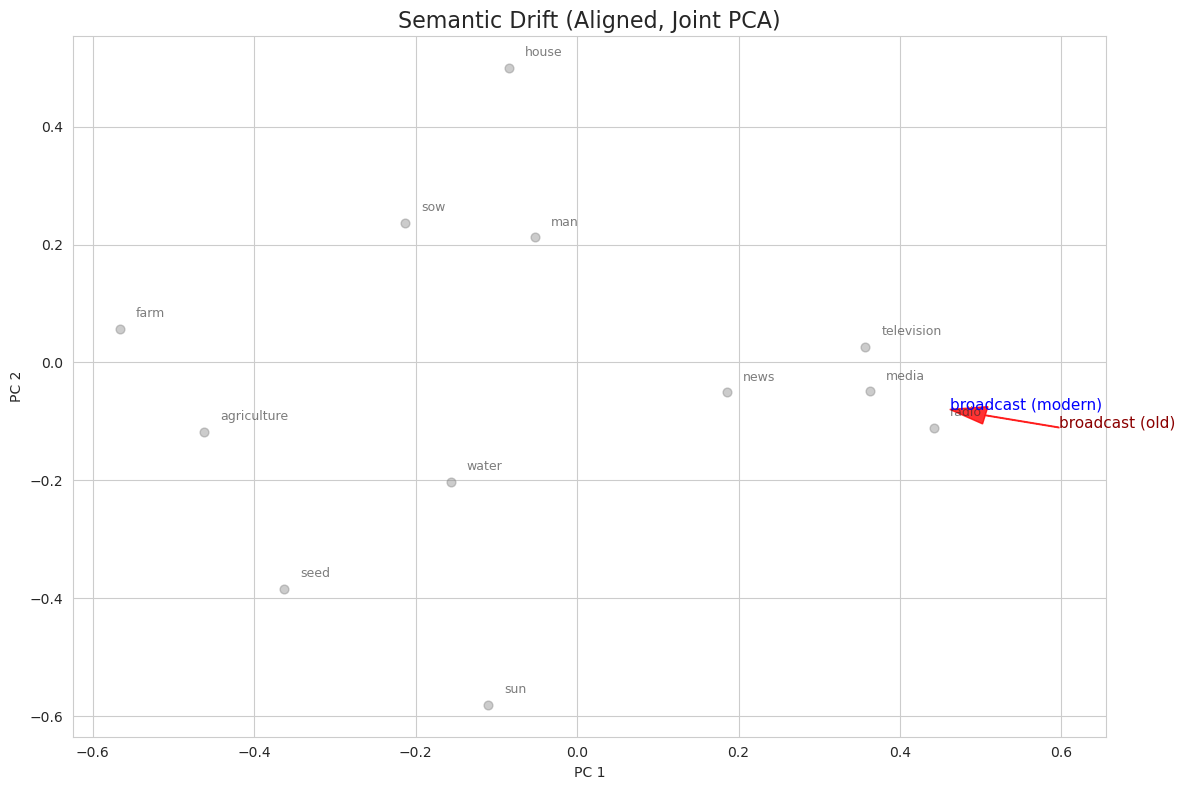

In [22]:
# sanity check to use twice the same model, there should be no drift!!!
mod_mod, mod_old, R, A_mean, B_mean, vocab = load_and_align_models(
    MODERN_PATH, PG19_PATH, IGNORE_LIST
)
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls

plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

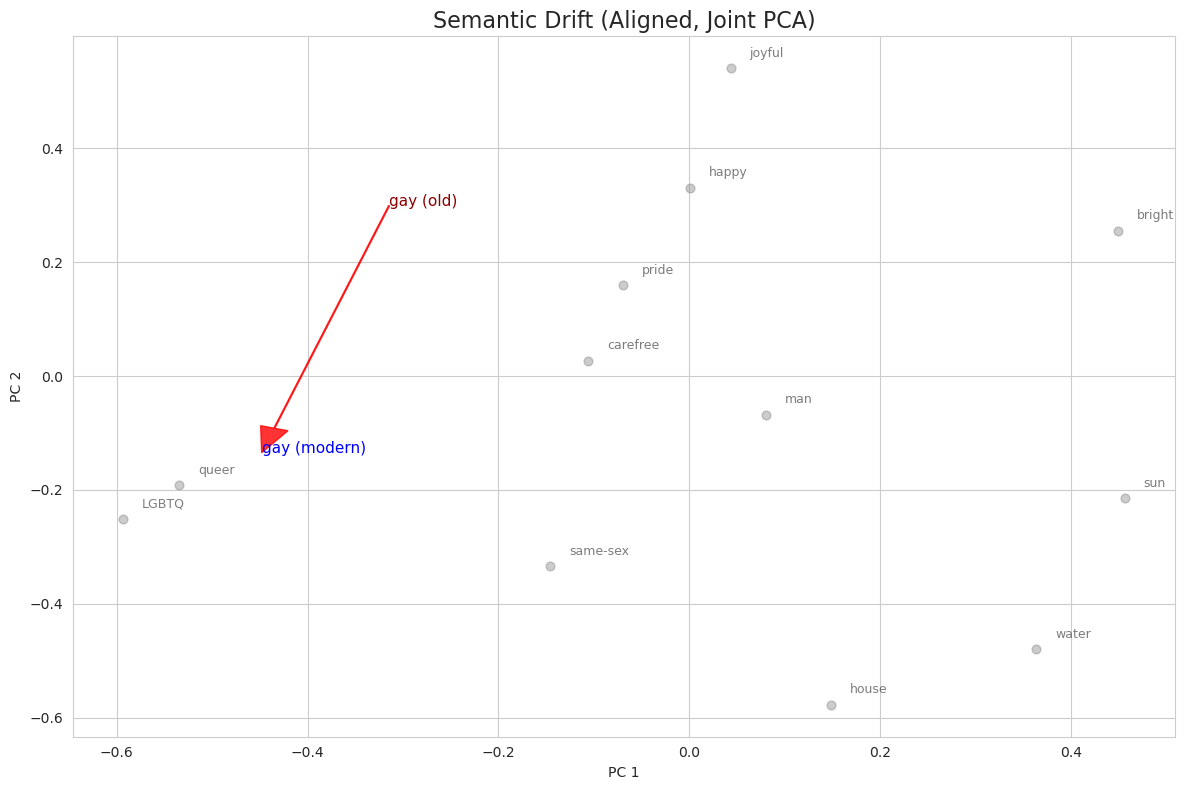

In [24]:
target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)


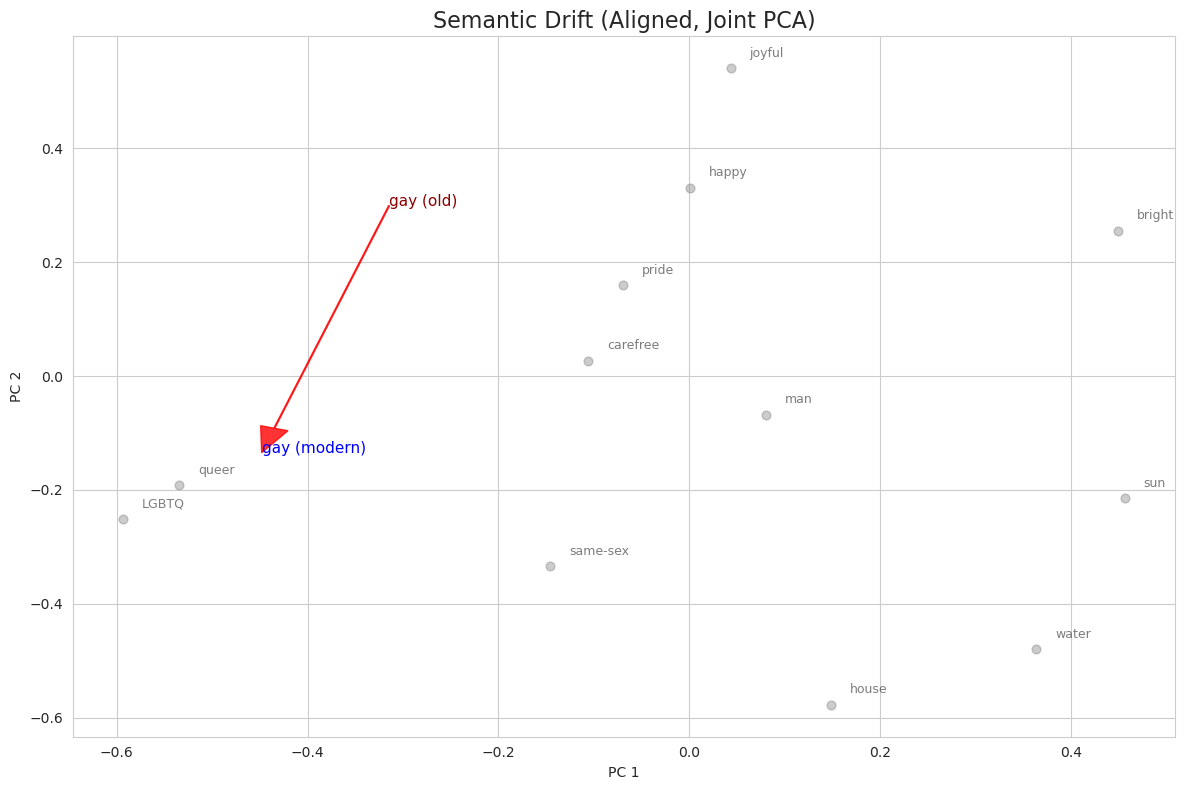

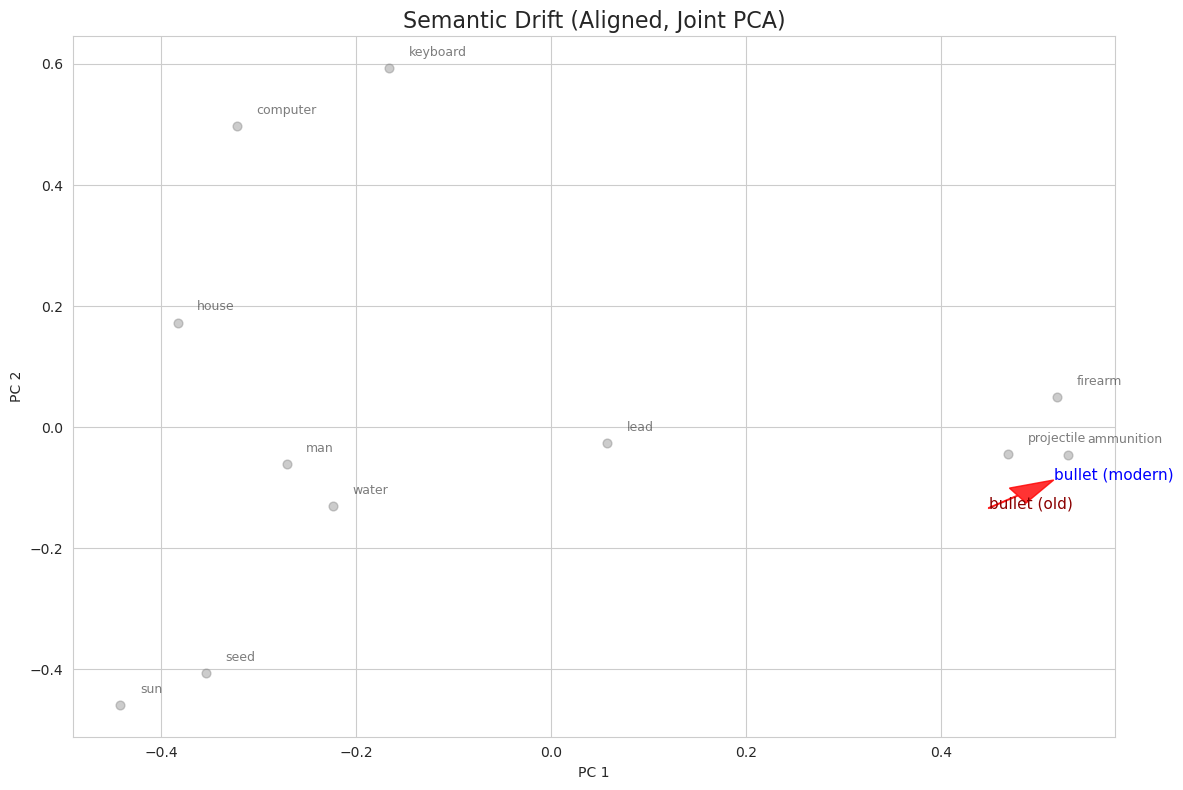

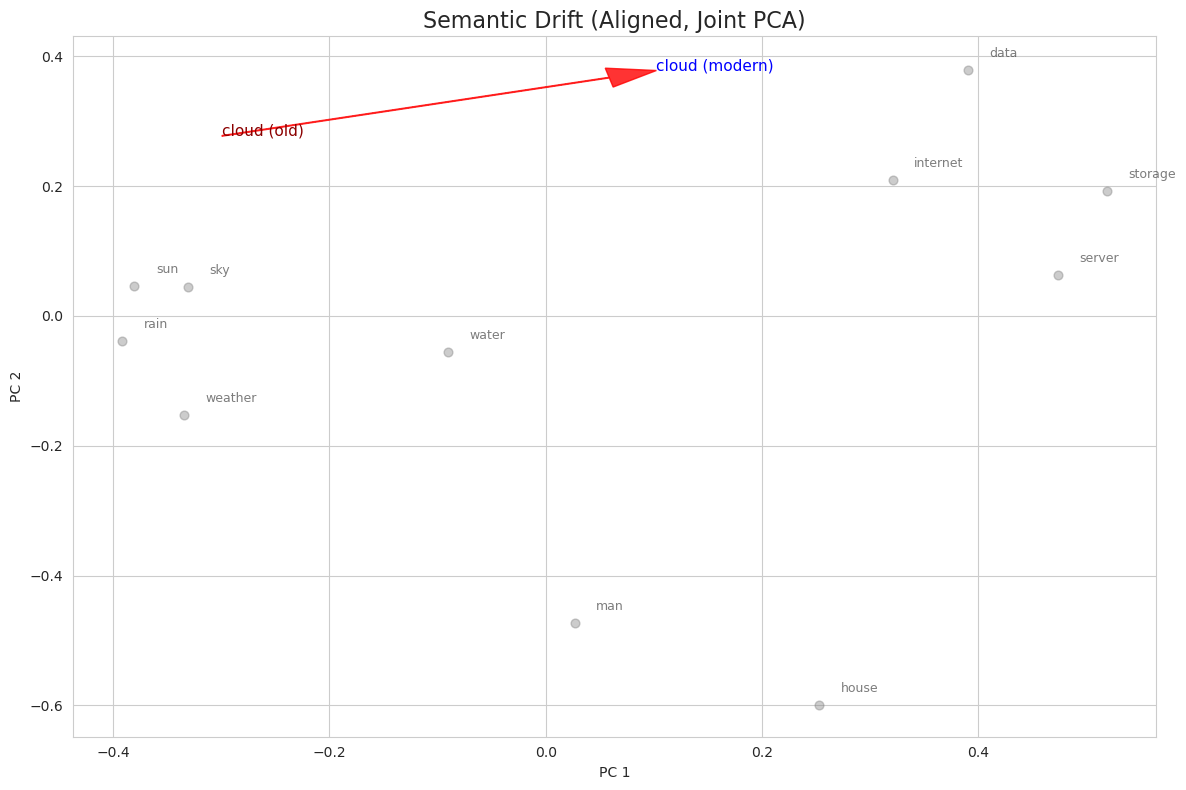

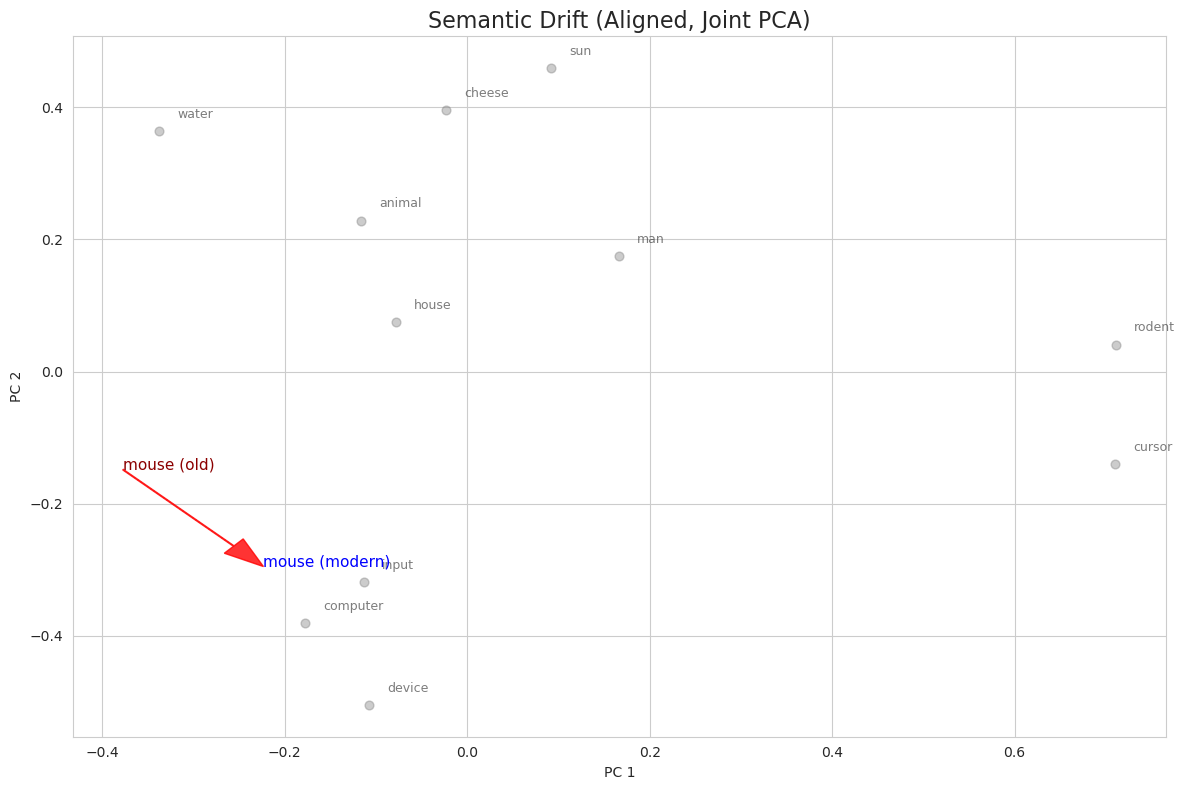

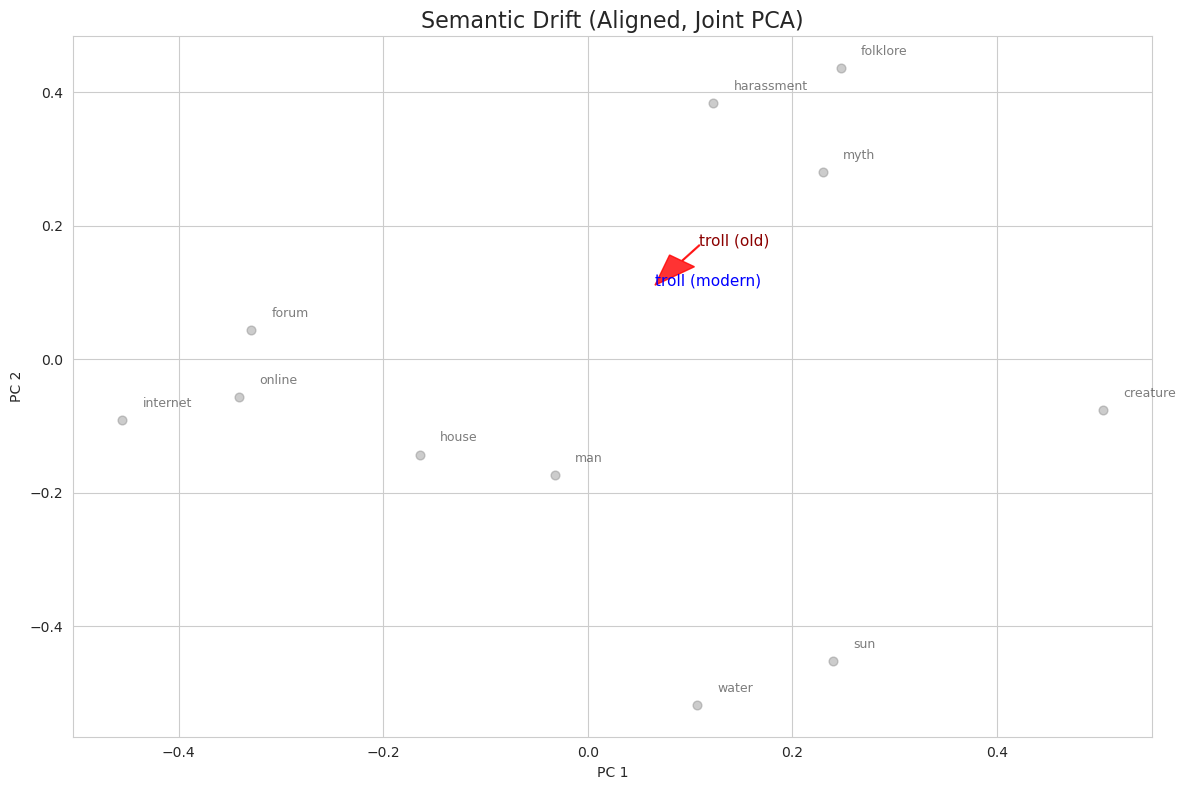

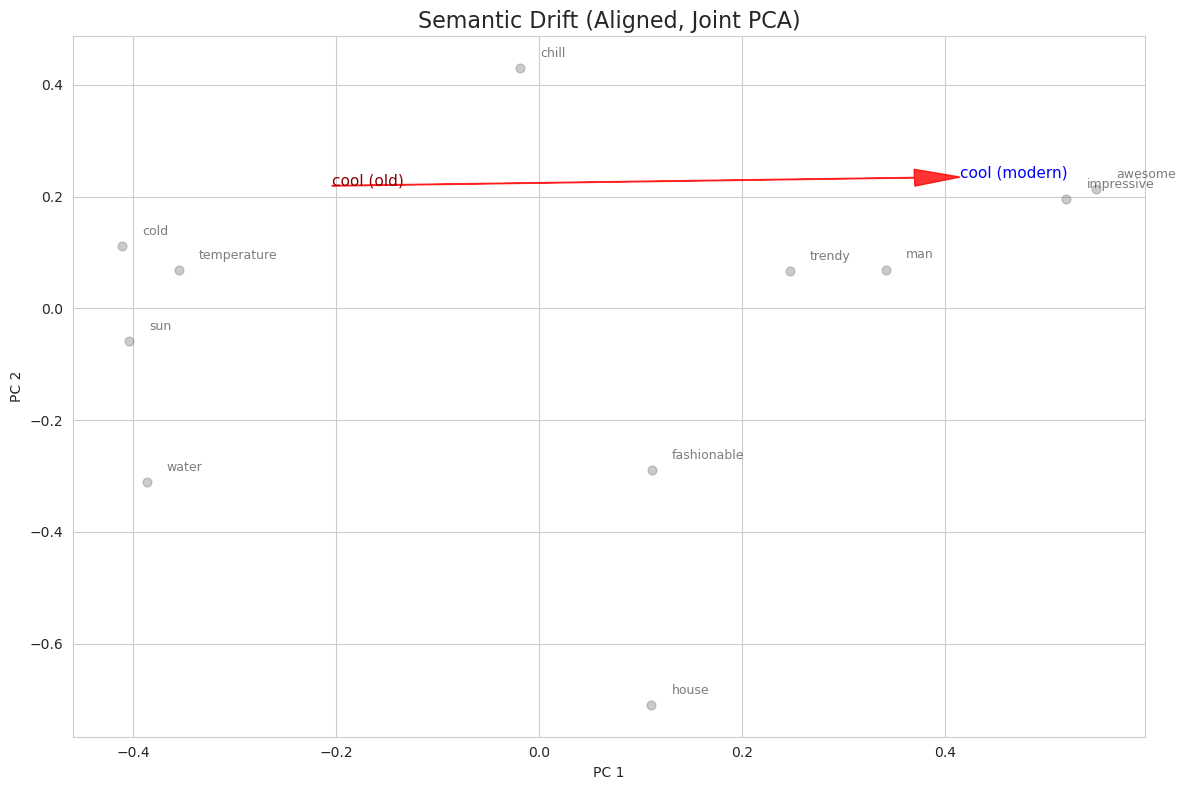

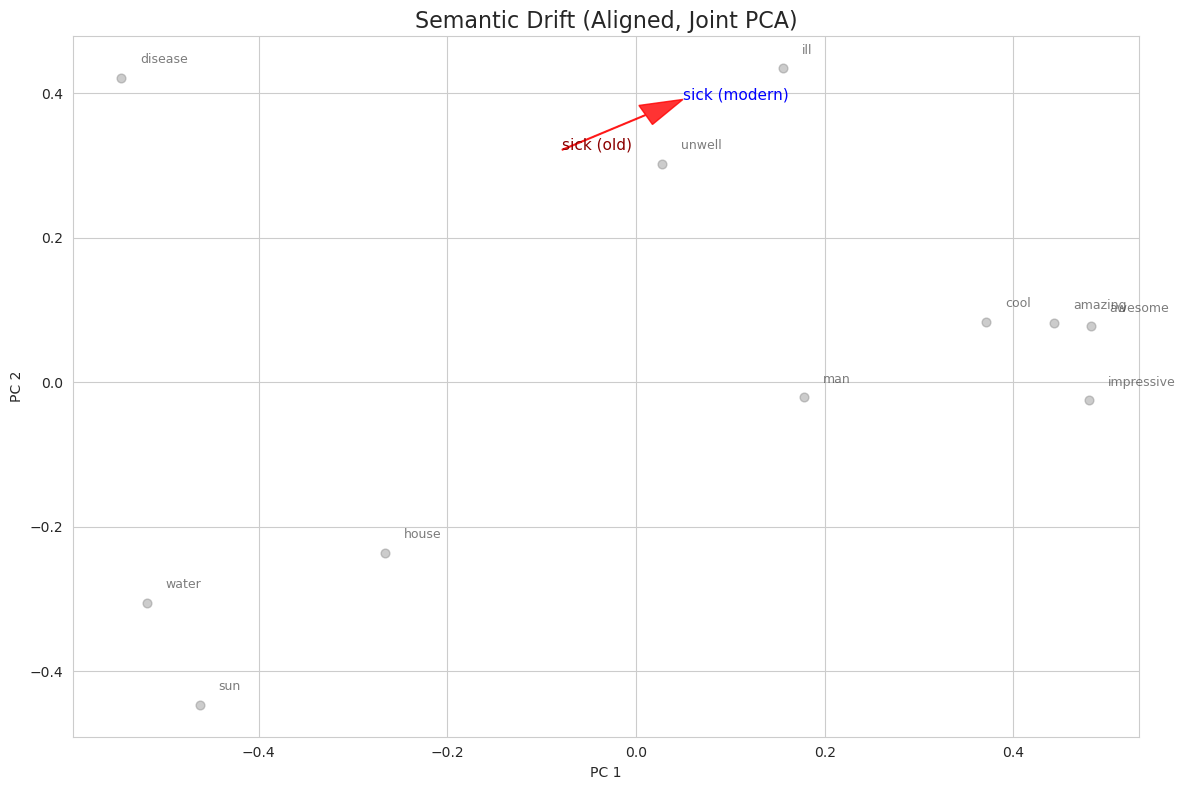

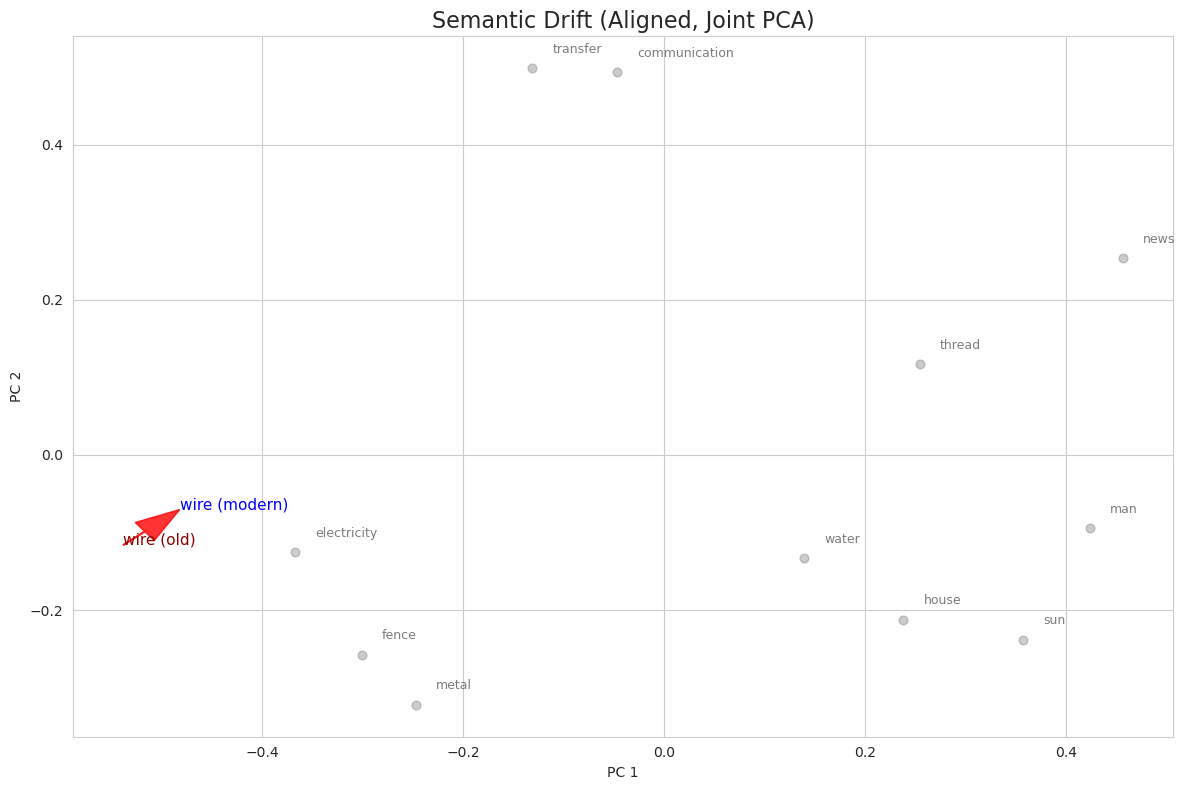

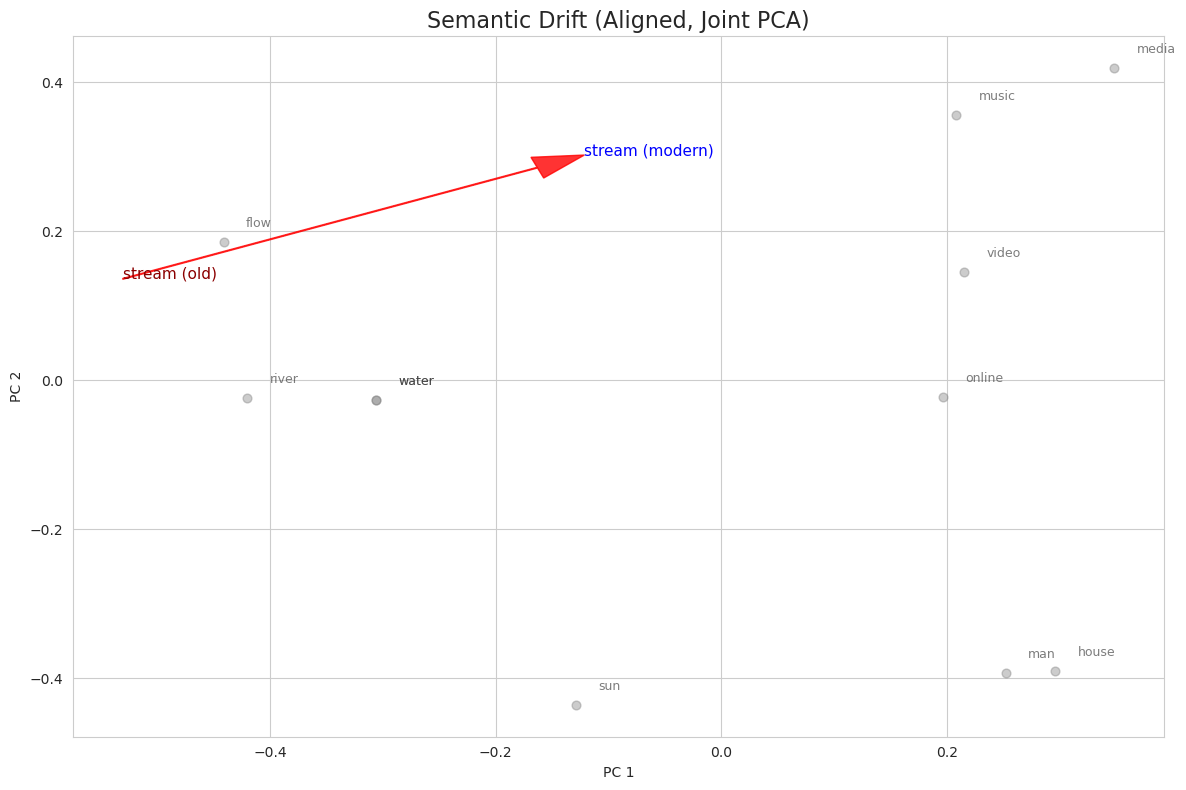

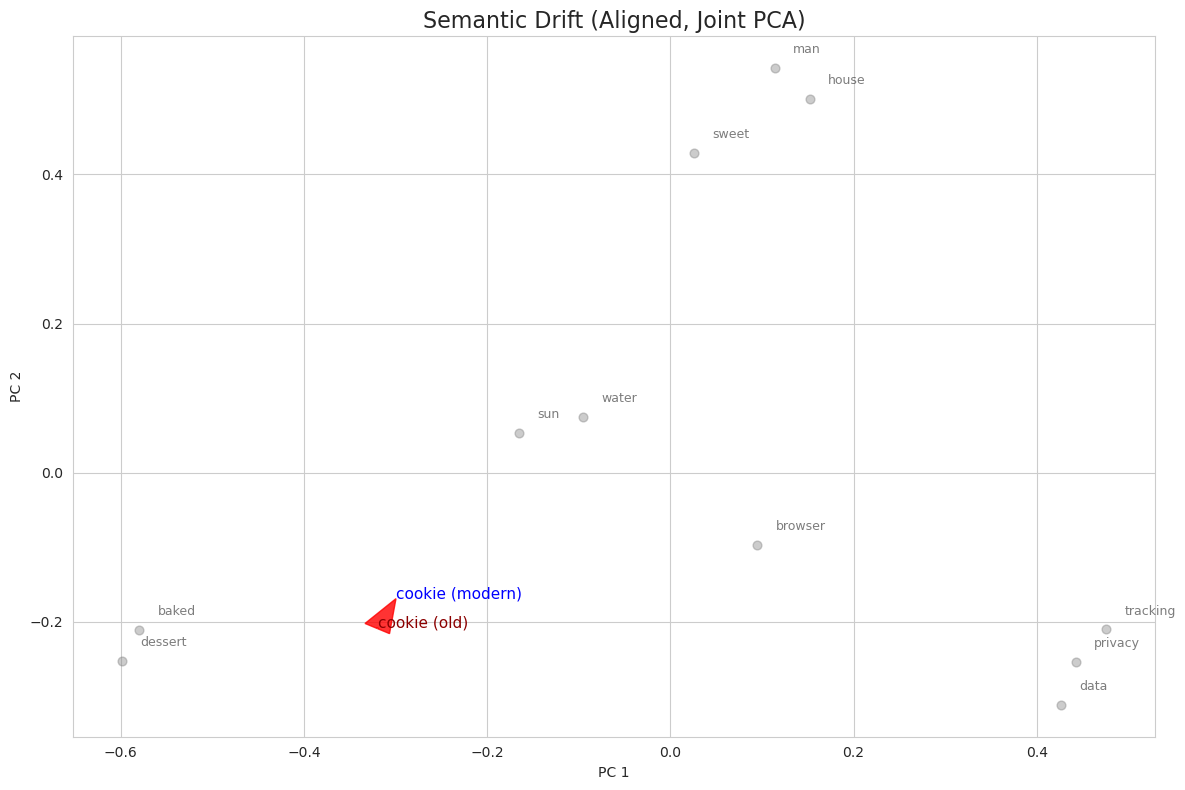

In [25]:
target_words = ["gay", "bullet", "cloud", "mouse", "troll", "cool", "sick", "wire", "stream", "cookie"]

anchors = {
    "gay": ["joyful", "carefree", "bright", "happy", "LGBTQ", "pride", "same-sex", "queer", "water", "sun", "man", "house"],
    "bullet": ["seed", "lead", "projectile", "firearm", "ammunition", "computer", "keyboard", "water", "sun", "man", "house"],
    "cloud": ["sky", "weather", "rain", "storage", "internet", "data", "server", "water", "sun", "man", "house"],
    "mouse": ["rodent", "animal", "cheese", "computer", "input", "device", "cursor", "water", "sun", "man", "house"],
    "troll": ["myth", "folklore", "creature", "internet", "harassment", "forum", "online", "water", "sun", "man", "house"],
    "cool": ["temperature", "chill", "cold", "fashionable", "impressive", "awesome", "trendy", "water", "sun", "man", "house"],
    "sick": ["ill", "disease", "unwell", "impressive", "awesome", "cool", "amazing", "water", "sun", "man", "house"],
    "wire": ["metal", "thread", "fence", "electricity", "communication", "transfer", "news", "water", "sun", "man", "house"],
    "stream": ["river", "water", "flow", "media", "video", "music", "online", "water", "sun", "man", "house"],
    "cookie": ["baked", "sweet", "dessert", "data", "browser", "tracking", "privacy", "water", "sun", "man", "house"]
}

# Plot for each target word
for target in target_words:
    plot_semantic_trajectory(mod_mod, mod_old, R, A_mean, B_mean, [target], anchors[target])

In [25]:
import os
import json
import re
from collections import Counter
from tqdm import tqdm

dataset = load_from_disk("data/pg19_processed_tokens")
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
ds_size = len(dataset)

def compute_and_store_word_counts(dataset, tokenizer, save_path="data/pg19_word_counts.json", batch_size=1000, overwrite=False):
    """
    Compute word counts over a HuggingFace `dataset` decoding with `tokenizer` in batches.
    If `save_path` exists and `overwrite` is False, loads and returns the saved counts.
    Returns a `collections.Counter` of word -> count.
    """
    if os.path.exists(save_path) and not overwrite:
        with open(save_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return Counter({k: int(v) for k, v in data.items()})

    cnt = Counter()
    ds_size = len(dataset)
    for i in tqdm(range(0, ds_size, batch_size), desc="Counting words"):
        batch = dataset[i: i + batch_size]
        # adjust field name if your dataset uses something else
        batch_ids = batch["input_ids"]
        texts = tokenizer.batch_decode(batch_ids, skip_special_tokens=True)
        for t in texts:
            words = re.findall(r"\b\w+\b", t.lower())
            cnt.update(words)

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump({k: int(v) for k, v in cnt.items()}, f, ensure_ascii=False)
    return cnt

def most_common_(word_counts, n=100, exclude=None, include=None):
    """
    Return top-n most common words not in `exclude` (case-insensitive).
    `word_counts` can be a Counter or a dict-like mapping.
    Optionally, specific words can be forced to be included via `include` list.
    """
    if include:
        include_set = set(w.lower() for w in include)
    exclude_set = set(w.lower() for w in (exclude or []))
    if not isinstance(word_counts, Counter):
        word_counts = Counter(word_counts)
    results = []
    for w, c in word_counts.most_common():
        if w in exclude_set:
            continue
        results.append((w, c))
        if len(results) >= n:
            break
    return results

def most_common(word_counts, n=100, exclude=None, include=None):
    """
    Return top-n most common words, forcing include words into the result.
    - word_counts can be a Counter or a dict-like mapping.
    - exclude is a list/set of words to omit unless they are in include.
    - include is an ordered list of words that must appear (in that order) if provided.
    Results are lower-cased.
    """
    exclude_set = set(w.lower() for w in (exclude or []))
    include_list = [w.lower() for w in (include or [])]
    include_set = set(include_list)
    exclude_set = exclude_set - include_set
    # normalize
    if not isinstance(word_counts, Counter):
        word_counts = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    else:
        word_counts = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    results = []
    added = set()
    for w in include_list:
        if w in added:
            continue
        c = word_counts.get(w, 0)
        results.append((w, c))
        added.add(w)
        if len(results) >= n:
            return results[:n]
    for w, c in word_counts.most_common():
        if w in exclude_set or w in added:
            continue
        results.append((w, c))
        added.add(w)
        if len(results) >= n:
            break
    return results[:n]

STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

wc = compute_and_store_word_counts(dataset, tokenizer, save_path="data/pg19_word_counts.json", batch_size=2000)

probes = ["broadcast", "monitor", "mouse"]  # Add more words as needed

stops = {"the","and","of","to","a","in","is","it","that","for","on","with","as","are"}
# TOP_ANCHORS = most_common_(wc, n=1_000, exclude=stops.union(probes), include=STABLE_ANCHORS)
TOP_ANCHORS = most_common_(wc, n=1_000, exclude=stops.union(probes), include=STABLE_ANCHORS)
#TOP_ANCHORS

In [28]:
def get_suitable_drift_words(word_counts, probes, min_count=50, min_selected=5, print_verdict=False):
    """
    Determine a subset of probes suitable for drift analysis based on occurrence counts.
    Args:
        word_counts: Counter or dict mapping word -> count (case-insensitive counts preferred).
        probes: iterable of probe word strings.
        print_verdict: if True, prints a small table of probe -> count -> verdict.
        min_count: initial minimum absolute count threshold for a probe to be considered 'Good'.
        min_selected: try to select at least this many probes by relaxing threshold if needed.

    Returns:
        List of selected probe words (lowercased) ordered by their count descending.
    """
    # Normalize word_counts to lowercase Counter
    if not isinstance(word_counts, Counter):
        wc = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    else:
        wc = Counter({k.lower(): int(v) for k, v in word_counts.items()})

    probes_norm = [p.lower() for p in probes]
    # Try thresholds, relaxing until we have at least min_selected or threshold reaches 1
    threshold = max(1, int(min_count))
    selected = []
    while True:
        selected = [(p, wc.get(p, 0)) for p in probes_norm if wc.get(p, 0) >= threshold]
        # sort by count desc
        selected.sort(key=lambda x: x[1], reverse=True)
        if len(selected) >= min_selected or threshold <= 1:
            break
        # Relax: halve threshold but at least 1
        threshold = max(1, threshold // 2)

    if print_verdict:
        header = f"{'WORD':<20} | {'COUNT':<10} | {'VERDICT'}"
        print(header)
        print("-" * len(header))
        for p in probes_norm:
            c = wc.get(p, 0)
            verdict = "✅ Good" if any(p == s for s, _ in selected) else "❌ Too Rare"
            print(f"{p:<20} | {c:<10} | {verdict}")

    # Return only the words (in original probe order filtered by presence in selected set),
    # but ordered by descending count to prefer higher-frequency probes.
    selected_words = list(set([w for w, _ in selected]))
    return selected_words

probes = ["broadcast", "monitor", "mouse", "intercourse", 
          "toilet", "traffic", "gay", "consumption",
          "cloud", "web", "cloud", "bug", "troll", "bullet", "like",
          "viral", "spam", "ghost", "qeer", 
          ]

DRIFT_WORDS = get_suitable_drift_words(wc, probes, min_count=100, min_selected=5, print_verdict=True)

WORD                 | COUNT      | VERDICT
-------------------------------------------
broadcast            | 40         | ❌ Too Rare
monitor              | 94         | ❌ Too Rare
mouse                | 469        | ✅ Good
intercourse          | 971        | ✅ Good
toilet               | 158        | ✅ Good
traffic              | 562        | ✅ Good
gay                  | 1796       | ✅ Good
consumption          | 381        | ✅ Good
cloud                | 1827       | ✅ Good
web                  | 238        | ✅ Good
cloud                | 1827       | ✅ Good
bug                  | 117        | ✅ Good
troll                | 32         | ❌ Too Rare
bullet               | 519        | ✅ Good
like                 | 50947      | ✅ Good
viral                | 0          | ❌ Too Rare
spam                 | 0          | ❌ Too Rare
ghost                | 1135       | ✅ Good
qeer                 | 0          | ❌ Too Rare


In [ ]:
import torch
import numpy as np
from model2vec import StaticModel
from scipy.spatial.distance import cdist

def get_nearest_neighbors(model, word, top_k=10):
    try:
        # 1. Encode the target word
        target_vec = model.encode([word]) # Shape (1, 384)
        
        # 2. Get the entire vocabulary and their vectors
        # Note: We extract the dictionary from the tokenizer
        vocab = list(model.tokenizer.get_vocab().keys())
        
        # Filter out subwords (tokens starting with ##) and short noise
        vocab = [w for w in vocab if len(w) > 3 and not w.startswith("##")]
        
        # This might be slow if vocab is huge, but fine for analysis
        # We batch encode to speed it up
        print(f"Scanning {len(vocab)} words in vocabulary...")
        all_vecs = model.encode(vocab)
        
        # 3. Calculate Cosine Distance (1 - Similarity)
        # cdist calculates distance between the target and ALL other words
        dists = cdist(target_vec, all_vecs, metric='cosine')[0]
        
        # 4. Sort and extract top K
        # We want the SMALLEST distance
        nearest_indices = np.argsort(dists)[:top_k]
        
        print(f"\n--- Neighbors for '{word}' ---")
        for i in nearest_indices:
            print(f"{vocab[i]:<15} (Dist: {dists[i]:.4f})")
            
    except KeyError:
        print(f"Word '{word}' not found in vocabulary.")

# --- RUN THE TEST ---
model_scratch = StaticModel.from_pretrained("models/pg19_scratch_static_final")
model_scratch = StaticModel.from_pretrained("models/pg19_aggressive_static_final")
#model_scratch = StaticModel.from_pretrained("models/pg19_static_final")
model_modern = StaticModel.from_pretrained("models/all-MiniLM-L6-v2_static")
# Check the drifters
for candidate in good_candidates:
    print(f"\n== Nearest Neighbors for '{candidate}':")
    print("-> Scratch Model:")
    get_nearest_neighbors(model_scratch, candidate)
    print("-> Modern Model:")
    get_nearest_neighbors(model_modern, candidate)


== Nearest Neighbors for 'monitor':
-> Scratch Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'monitor' ---
▁monitor        (Dist: 0.0000)
▁monitors       (Dist: 0.1892)
▁lcd            (Dist: 0.2970)
▁screen         (Dist: 0.3150)
screen          (Dist: 0.3150)
▁display        (Dist: 0.3530)
▁monitoring     (Dist: 0.3538)
▁monitored      (Dist: 0.3833)
▁television     (Dist: 0.4154)
▁scanner        (Dist: 0.4224)
-> Modern Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'monitor' ---
▁monitor        (Dist: 0.0000)
▁monitors       (Dist: 0.1095)
▁displays       (Dist: 0.2871)
▁screens        (Dist: 0.3365)
screen          (Dist: 0.3649)
▁screen         (Dist: 0.3649)
▁lcd            (Dist: 0.4080)
▁display        (Dist: 0.4092)
▁monitoring     (Dist: 0.4245)
▁monitored      (Dist: 0.4479)

== Nearest Neighbors for 'mouse':
-> Scratch Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'mouse' ---
▁mouse          (Dist: 0.0000)
▁mice        

In [ ]:
# good words --> cloud, gay, traffic, intercourse,

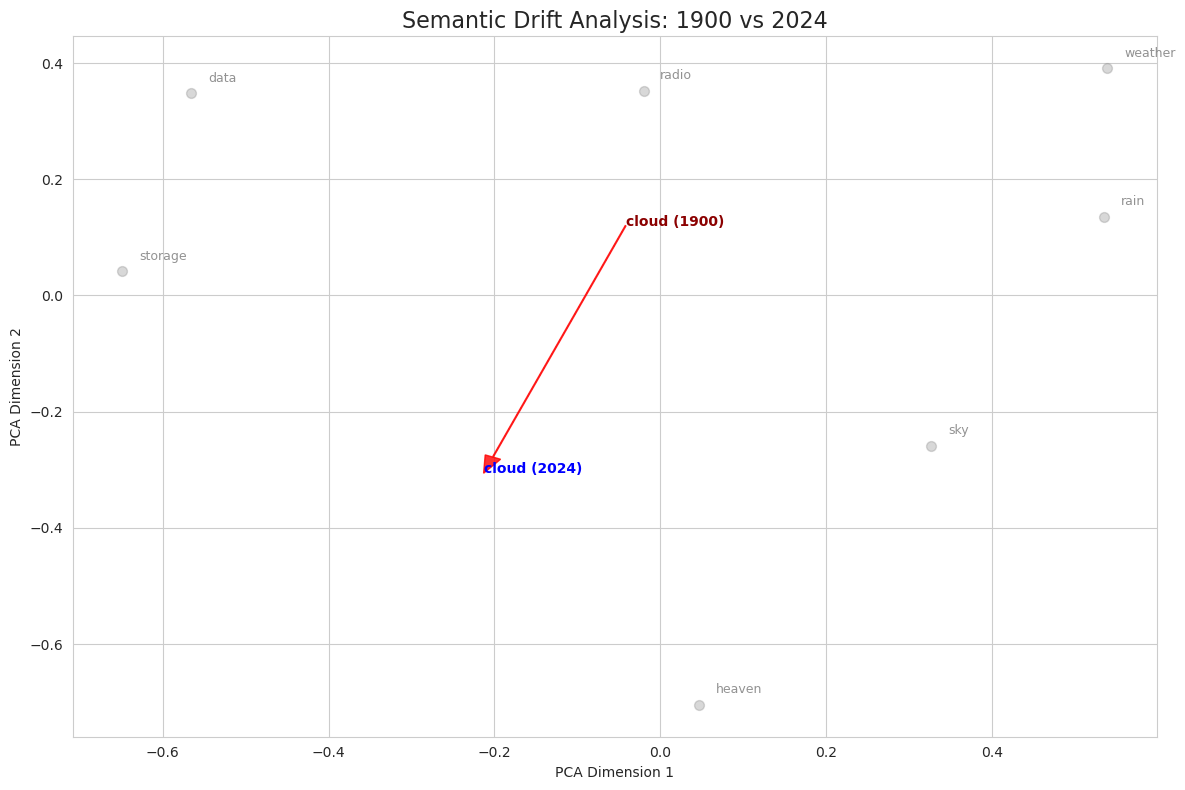

In [ ]:
plot_semantic_trajectory(model_modern, model_scratch, Rotation, ['cloud'], ['sky', 'heaven', 'weather', 'data', 'storage', 'radio', 'rain',])

Loading models...
Common vocabulary size: 27007
Alignment rotation calculated.


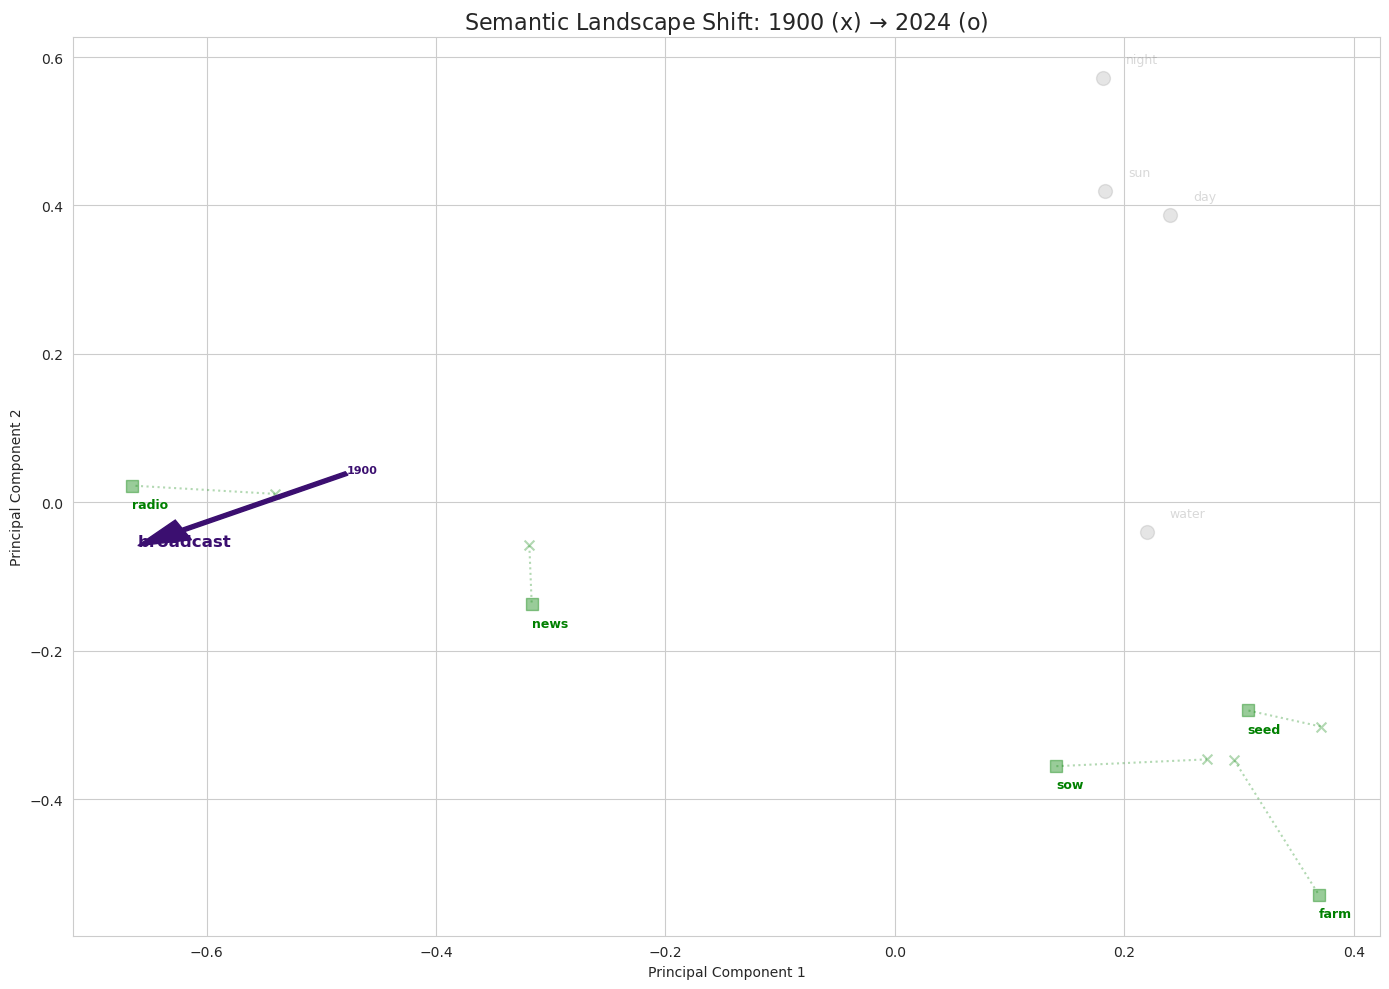

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from model2vec import StaticModel
from scipy.linalg import orthogonal_procrustes

# [Keep your existing load_and_align_models function]

def plot_semantic_trajectory_v2(mod_modern, mod_pg19, R, target_words, context_anchors, control_anchors):
    """
    Plots the movement of target words AND context words to show landscape shifts.
    
    Args:
        target_words: The main drifters (e.g., "broadcast")
        context_anchors: Words defining the meanings (e.g., "farm", "radio")
        control_anchors: Stable words defining the map (e.g., "water", "sun")
    """
    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")
    
    # 1. Define the Coordinate System (The "Map")
    # We build the PCA map using ONLY the Modern vectors of all words.
    # This keeps the axes consistent: X-axis = "Modern Meaning Dimension 1"
    all_words = list(set(target_words + context_anchors + control_anchors))
    base_vectors = mod_modern.encode(all_words)
    
    pca = PCA(n_components=2)
    pca.fit(base_vectors) # Fit the "Modern World" coordinates
    
    # Helper to plot a single point
    def get_pos(model, word, rotation=None):
        vec = model.encode([word])[0]
        if rotation is not None:
            vec = vec @ rotation # Align PG19 to Modern
        return pca.transform([vec])[0]

    # 2. Plot Stable Controls (Grey Background)
    # We assume these are static, so we just plot the Modern position to reduce clutter
    for word in control_anchors:
        pos = get_pos(mod_modern, word)
        plt.scatter(pos[0], pos[1], alpha=0.2, color='gray', s=100)
        plt.text(pos[0]+0.02, pos[1]+0.02, word, alpha=0.3, fontsize=9, color='gray')

    # 3. Plot Context Anchors (The Changing Landscape)
    # We show where "Radio" was in 1900 vs 2024
    for word in context_anchors:
        # Modern Position (The "Target" Meaning)
        pos_mod = get_pos(mod_modern, word)
        plt.scatter(pos_mod[0], pos_mod[1], marker='s', color='green', alpha=0.4, s=80)
        plt.text(pos_mod[0], pos_mod[1]-0.03, f"{word}", fontsize=9, color='green', fontweight='bold')
        
        # PG-19 Position (Does this concept even exist?)
        pos_old = get_pos(mod_pg19, word, rotation=R)
        
        # Draw a faint dotted line connecting them to show context drift
        plt.plot([pos_old[0], pos_mod[0]], [pos_old[1], pos_mod[1]], 
                 linestyle=':', color='green', alpha=0.3)
        plt.scatter(pos_old[0], pos_old[1], marker='x', color='green', alpha=0.3, s=50)

    # 4. Plot Target Trajectories (The Main Event)
    colors = plt.cm.magma(np.linspace(0.2, 0.8, len(target_words)))
    
    for i, word in enumerate(target_words):
        pos_mod = get_pos(mod_modern, word)
        pos_old = get_pos(mod_pg19, word, rotation=R)
        
        # Draw bold arrow
        plt.arrow(pos_old[0], pos_old[1], 
                  pos_mod[0]-pos_old[0], pos_mod[1]-pos_old[1], 
                  head_width=0.03, color=colors[i], alpha=1.0, width=0.005, length_includes_head=True, zorder=10)
        
        # Labels
        plt.text(pos_old[0], pos_old[1], f"1900", color=colors[i], fontsize=8, fontweight='bold')
        plt.text(pos_mod[0], pos_mod[1], f"{word}", color=colors[i], fontsize=12, fontweight='bold')

    plt.title("Semantic Landscape Shift: 1900 (x) $\u2192$ 2024 (o)", fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()

# --- EXECUTION EXAMPLE ---

# Run the alignment first (from your script)
mod_mod, mod_old, Rotation, common_vocab = load_and_align_models()

# Plot Broadcast
target = ["broadcast"]
context_anchors = ["farm", "seed", "sow",    # Farming Context
                   "radio", "news"]          # Tech Context (Expect these to move or represent noise in 1900)
control_anchors = ["water", "sun", "day", "night"]

plot_semantic_trajectory_v2(mod_mod, mod_old, Rotation, target, context_anchors, control_anchors)

In [38]:
TOP_ANCHORS_WORDS = [w for w, _ in TOP_ANCHORS]

Aligning models using 15 strict anchors...


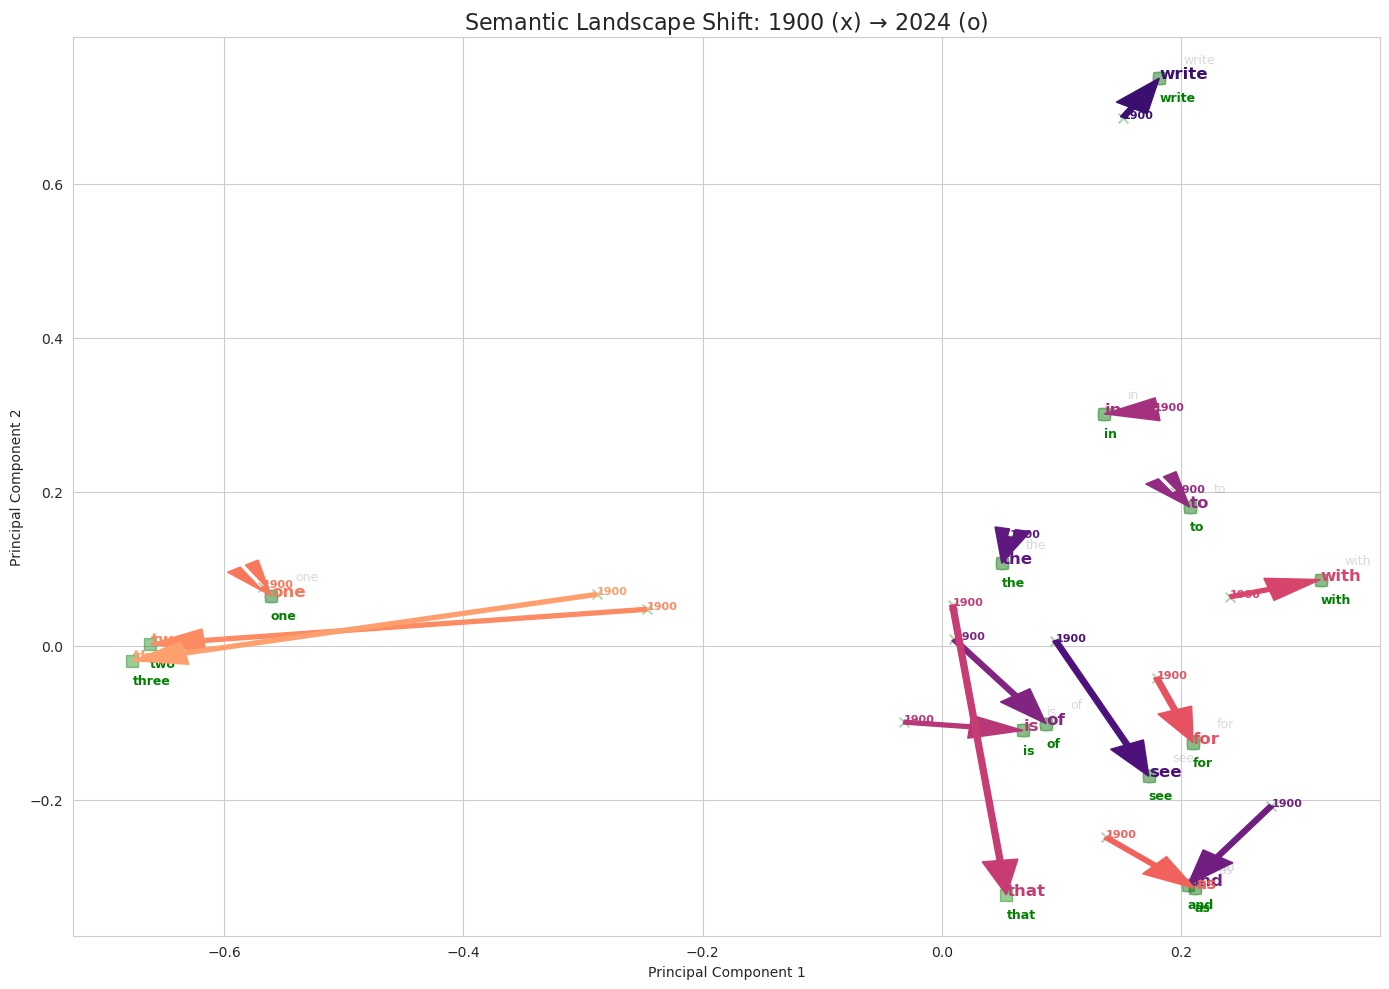

In [49]:
import numpy as np
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes

# 1. Define the "Gold Standard" Anchors (Immutable Concepts)
# These words are extremely unlikely to have drifted.
STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

def align_strictly_and_plot(mod_modern, mod_pg19, target_words, context_words, anchors=STABLE_ANCHORS[-15:]):
    """
    Aligns vectors using ONLY the Stable Anchor list, then projects the target/context words.
    """
    
    # --- STEP 1: CALCULATE ROTATION (Using only STABLE words) ---
    print(f"Aligning models using {len(anchors)} strict anchors...")
    
    # Filter anchors to ensure they exist in both models
    valid_anchors = [w for w in anchors 
                     if w in mod_modern.tokenizer.get_vocab() 
                     and w in mod_pg19.tokenizer.get_vocab()]
    
    if not valid_anchors:
        raise ValueError("No valid anchors found in both vocabularies. Please check your anchors list or vocabularies.")
    
    # Encode Anchors
    vecs_mod = mod_modern.encode(valid_anchors)
    vecs_old = mod_pg19.encode(valid_anchors)
    
    # Calculate Rotation Matrix R
    # This aligns the "Background Reality" of 1900 to 2024
    R, _ = orthogonal_procrustes(vecs_old, vecs_mod)
    #R = np.zeros_like(R)
    #R = np.eye(R.shape[0])  # Identity matrix for no rotation
    
    # --- STEP 2: APPLY ROTATION TO TARGETS ---
    # Now we project the "Context" words. 
    # Because we didn't use them to align, their movement is GENUINE.
    
    # (Reuse the plotting code from the previous response here)
    # When plotting, use the R we just calculated.
    plot_semantic_trajectory_v2(
        mod_modern, 
        mod_pg19, 
        R,             # The strict rotation
        target_words, 
        context_words, 
        valid_anchors  # Plot anchors lightly as background
    )

# Example Usage
align_strictly_and_plot(
    mod_modern=mod_mod, 
    mod_pg19=mod_old, 
    #mod_pg19=mod_mod, 
    # target_words=["broadcast"], 
    # context_words=["farm", "seed", "radio", "news"],
    # target_words=["cloud"], 
    # context_words=["sky", "rain", "storm", "dark", "shadow", "vapor", "mist", "data", "storage", "internet", "server"],
    target_words=STABLE_ANCHORS[-15:], 
    context_words=STABLE_ANCHORS[-15:],
)

In [50]:
import numpy as np

def ensure_eval_mode(model):
    # If model is a PyTorch module, put it in eval() to disable dropout
    try:
        model.model.eval()
    except Exception:
        try:
            model.eval()
        except Exception:
            pass

def _get_anchor_vectors(model, anchors):
    # Assumes `model.encode(list_of_words)` returns one vector per word.
    # If your StaticModel uses subword tokens internally, ensure `encode`
    # is doing an appropriate pooling (one vector per word).
    vecs = model.encode(anchors)
    return np.asarray(vecs, dtype=np.float64)

def fit_procrustes(src_vecs, tgt_vecs):
    """
    Compute orthogonal rotation R, scale s, and means for full Procrustes:
      aligned = (src - mean_src) @ R * s + mean_tgt
    Returns (R, scale, mean_src, mean_tgt).
    """
    src = np.asarray(src_vecs, dtype=np.float64)
    tgt = np.asarray(tgt_vecs, dtype=np.float64)
    assert src.shape == tgt.shape, "src/tgt shapes differ"

    mean_src = src.mean(axis=0)
    mean_tgt = tgt.mean(axis=0)
    src_c = src - mean_src
    tgt_c = tgt - mean_tgt

    # SVD on cross-covariance
    C = src_c.T @ tgt_c
    U, S, Vt = np.linalg.svd(C, full_matrices=False)
    R = U @ Vt

    var_src = (src_c ** 2).sum()
    scale = S.sum() / var_src if var_src > 0 else 1.0

    return R, scale, mean_src, mean_tgt

def apply_procrustes(vecs, R, scale, mean_src, mean_tgt):
    v = np.asarray(vecs, dtype=np.float64)
    return (v - mean_src) @ R * scale + mean_tgt

def procrustes_alignment_and_diagnostics(mod_source, mod_target, anchors, min_anchors=10, verbose=True):
    """
    Anchors: list of words. Uses model.encode(anchors) for both models.
    Returns (R, scale, mean_src, mean_tgt, diagnostics_dict).
    """
    ensure_eval_mode(mod_source)
    ensure_eval_mode(mod_target)

    # Filter anchors present in both tokenizers if possible
    valid_anchors = []
    try:
        vocab_src = set(mod_source.tokenizer.get_vocab())
        vocab_tgt = set(mod_target.tokenizer.get_vocab())
        for w in anchors:
            if w in vocab_src and w in vocab_tgt:
                valid_anchors.append(w)
    except Exception:
        # fallback: use the provided anchors as-is
        valid_anchors = anchors[:]

    if verbose:
        print("Anchors available:", len(valid_anchors), " / ", len(anchors))
    if len(valid_anchors) < min_anchors and verbose:
        print("Warning: few anchors. Consider adding more or verifying tokenization.")

    vecs_src = _get_anchor_vectors(mod_source, valid_anchors)
    vecs_tgt = _get_anchor_vectors(mod_target, valid_anchors)

    R, scale, mean_src, mean_tgt = fit_procrustes(vecs_src, vecs_tgt)
    aligned_src = apply_procrustes(vecs_src, R, scale, mean_src, mean_tgt)

    # Diagnostics
    diffs = aligned_src - vecs_tgt
    dists = np.linalg.norm(diffs, axis=1)
    cos_sim = lambda a,b: (a@b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
    cos_sims = [cos_sim(aligned_src[i], vecs_tgt[i]) for i in range(len(valid_anchors))]

    diagnostics = {
        "n_anchors": len(valid_anchors),
        "mean_l2_error": float(dists.mean()),
        "max_l2_error": float(dists.max()),
        "median_l2_error": float(np.median(dists)),
        "mean_cos_sim": float(np.mean(cos_sims)),
    }
    if verbose:
        print("Procrustes diagnostics:", diagnostics)
    return R, scale, mean_src, mean_tgt, diagnostics

Loading Models...


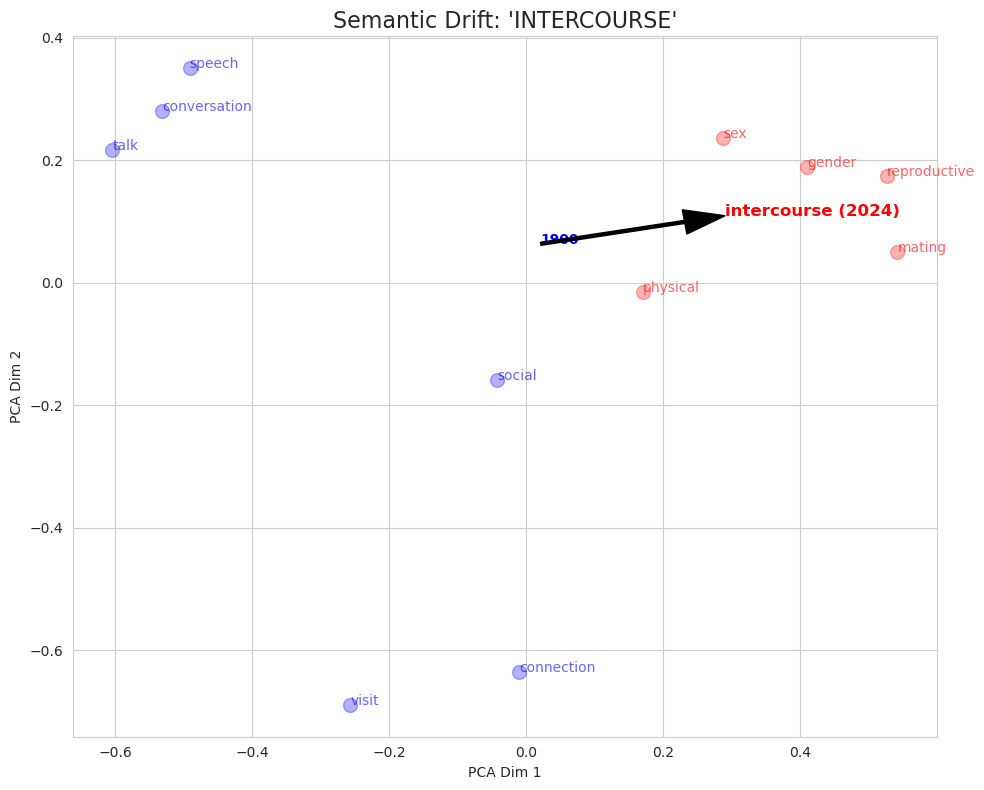

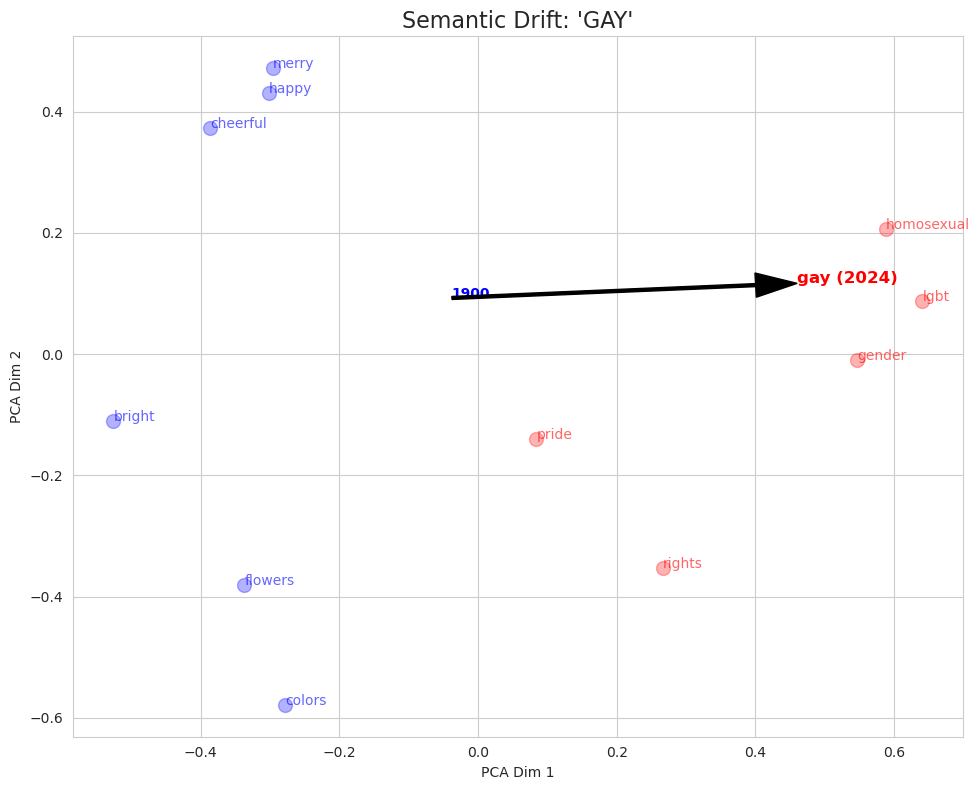

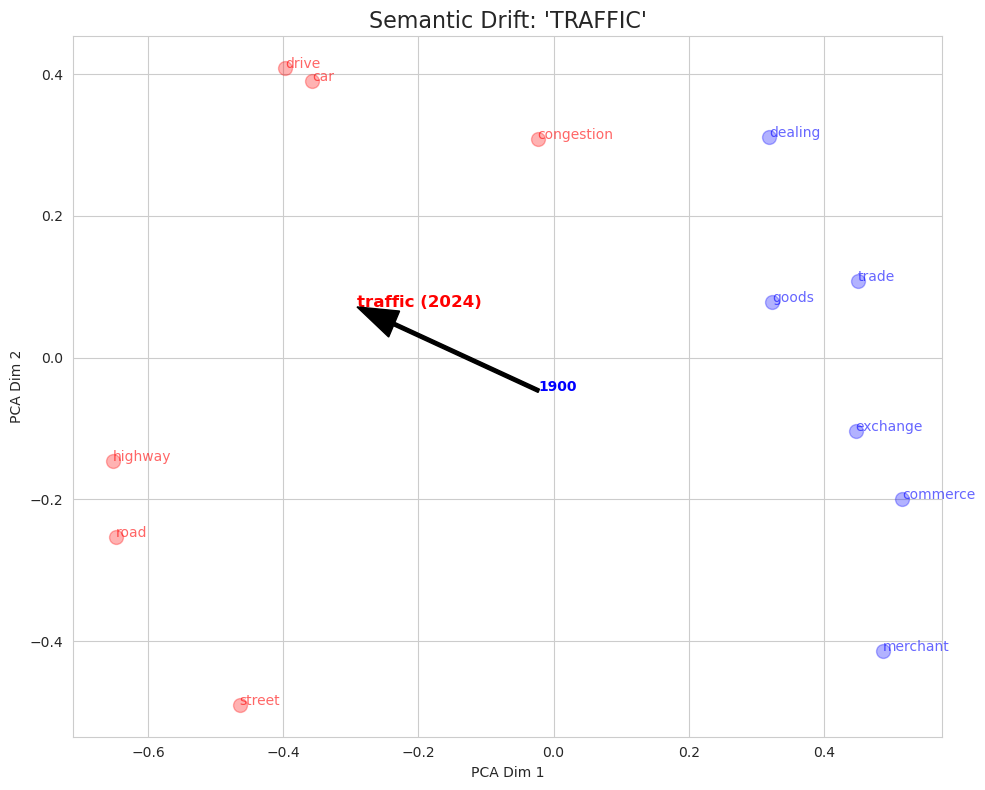

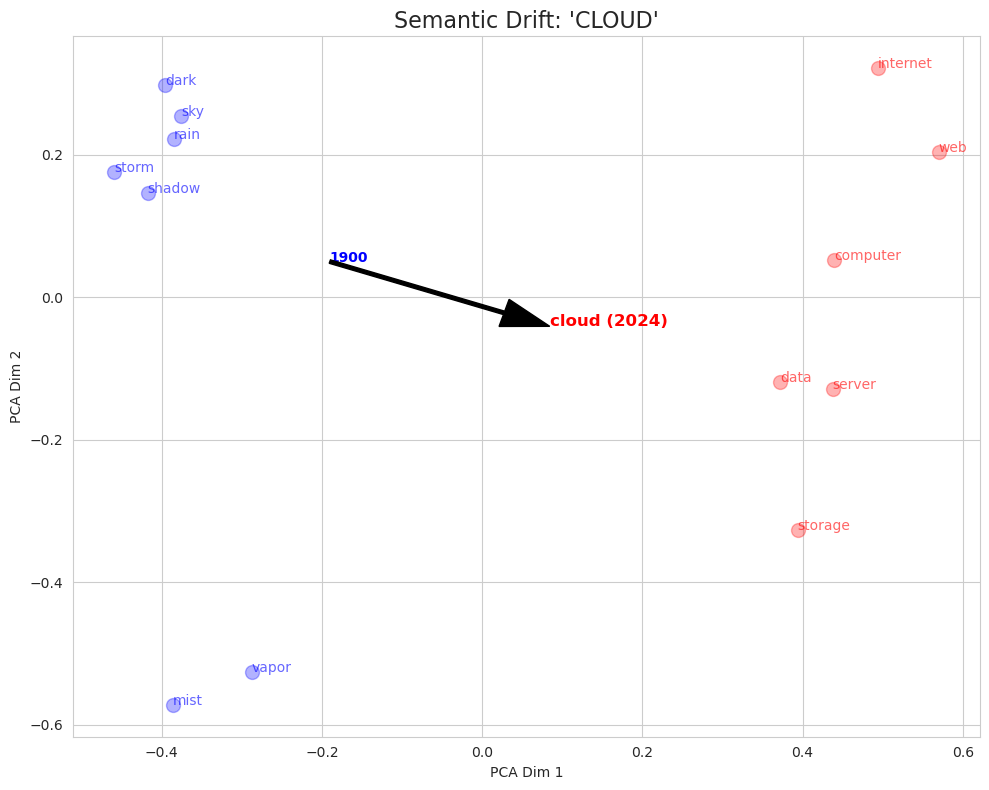

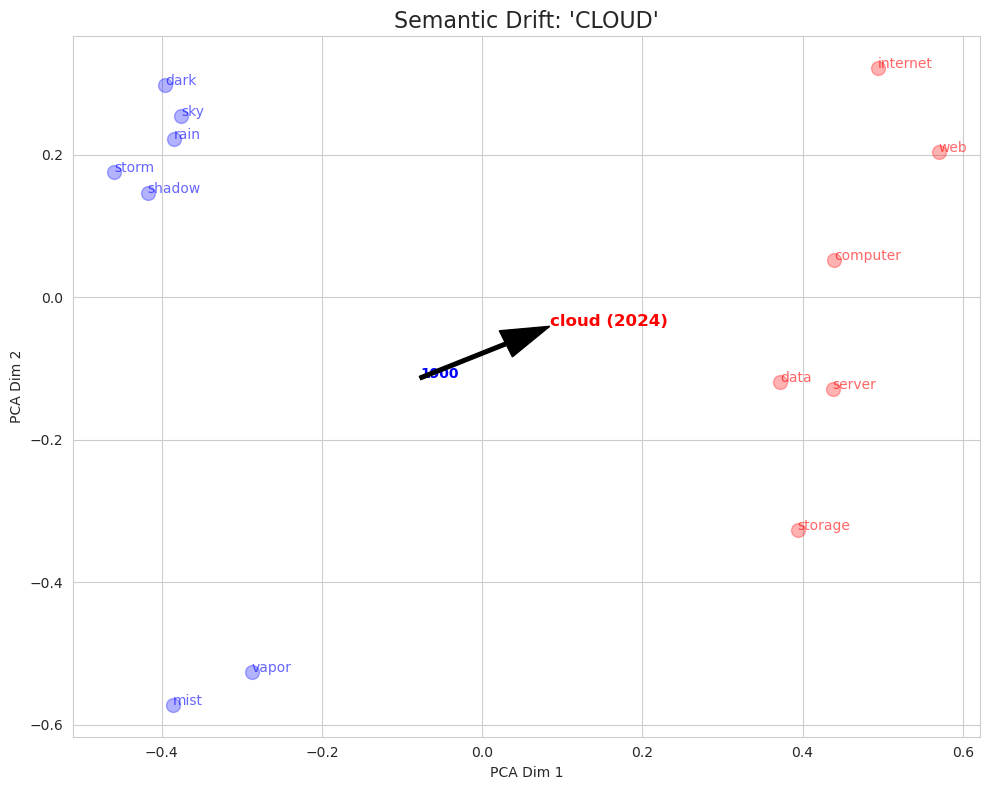

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel

# --- 1. CONFIGURATION ---
MODERN_PATH_ALL_MINILM = "minishlab/potion-base-8m"           # Base Model from library
MODERN_PATH_ALL_MINILM = "models/all-MiniLM-L6-v2_static"          # Base Model from sentence-transformers
PG19_PRE_TRAINED_FROM_SCRATCH_PATH   = "models/pg19_scratch_static_final"   #  Fine-Tuned Model
PG19_WEAK_FINE_TUNED_PATH   = "models/pg19_static_final"   #  Fine-Tuned Model
PG19_AGGRESSIVE_FINE_TUNED_PATH   = "models/pg19_aggressive_static_final"   #  Fine-Tuned Model

# "Strict Anchors" - Words that definitely did NOT change.
# We use these to lock the two coordinate systems together.
STABLE_ANCHORS = [
    "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
    "summer", "winter", "north", "south", "east", "west", "hand", "foot",
    "head", "mother", "father", "son", "daughter", "man", "woman", "life",
    "death", "eat", "drink", "walk", "speak", "the", "and", "of", "to"
]

# --- 2. ALIGNMENT & PLOTTING ENGINE ---

def plot_drift(mod_modern, mod_pg19, target_word, old_context, new_context):
    """
    Aligns the 1900 model to the 2024 model using Stable Anchors,
    then plots the specific drift of the target word.
    """
    
    # A. Align Models (Procrustes)
    # ---------------------------
    # Only use words that exist in both vocabularies
    valid_anchors = [w for w in STABLE_ANCHORS 
                     if w in mod_modern.tokenizer.get_vocab() 
                     and w in mod_pg19.tokenizer.get_vocab()]
    
    vecs_mod = mod_modern.encode(valid_anchors)
    vecs_old = mod_pg19.encode(valid_anchors)
    
    # Calculate Rotation Matrix R (Aligns Old -> Modern)
    R, _ = orthogonal_procrustes(vecs_old, vecs_mod)
    
    # B. Setup Plotting Data
    # ----------------------
    # We build the map using Modern vectors for context words
    all_context = old_context + new_context + valid_anchors[:10] # Add some anchors for background
    base_vectors = mod_modern.encode(all_context)
    
    # Fit PCA on the Modern Contexts (This defines the "2024 Map")
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    # Helper to project words into 2D
    def get_pos(model, word, rotation=None):
        vec = model.encode([word])[0]
        if rotation is not None:
            vec = vec @ R # Apply alignment
        return pca.transform([vec])[0]

    # C. Plot The Map (Context Clusters)
    # --------------------------------
    # 1. Plot Old Contexts (e.g. "Conversation") - Blue
    for w in old_context:
        pos = get_pos(mod_modern, w)
        plt.scatter(pos[0], pos[1], c='blue', alpha=0.3, s=100)
        plt.text(pos[0], pos[1], w, color='blue', alpha=0.6, fontsize=10)

    # 2. Plot New Contexts (e.g. "Sex") - Red
    for w in new_context:
        pos = get_pos(mod_modern, w)
        plt.scatter(pos[0], pos[1], c='red', alpha=0.3, s=100)
        plt.text(pos[0], pos[1], w, color='red', alpha=0.6, fontsize=10)

    # D. Plot The Drifting Target
    # -------------------------
    # 1. Start Position (1900)
    pos_start = get_pos(mod_pg19, target_word, rotation=R)
    
    # 2. End Position (2024)
    pos_end = get_pos(mod_modern, target_word)
    
    # Draw Arrow
    plt.arrow(pos_start[0], pos_start[1], 
              pos_end[0]-pos_start[0], pos_end[1]-pos_start[1], 
              head_width=0.04, color='black', width=0.005, length_includes_head=True, zorder=10)
    
    plt.text(pos_start[0], pos_start[1], "1900", color='blue', fontweight='bold', fontsize=10)
    plt.text(pos_end[0], pos_end[1], f"{target_word} (2024)", color='red', fontweight='bold', fontsize=12)
    
    plt.title(f"Semantic Drift: '{target_word.upper()}'", fontsize=16)
    plt.xlabel("PCA Dim 1")
    plt.ylabel("PCA Dim 2")
    plt.tight_layout()
    plt.show()

# --- 3. EXECUTION ---

print("Loading Models...")
model_modern = StaticModel.from_pretrained(MODERN_PATH)
model_pg19 = StaticModel.from_pretrained(PG19_PATH)

# --- 4. RUN ANALYSIS FOR YOUR WORDS ---

# 1. INTERCOURSE (The clearest example)
# Moves from "Conversation" -> "Sex"
plot_drift(
    model_modern, model_pg19,
    target_word="intercourse",
    old_context=["conversation", "social", "speech", "talk", "visit", "connection"],
    new_context=["sex", "physical", "reproductive", "mating", "gender"]
)

# 2. GAY
# Moves from "Happy" -> "Homosexual"
plot_drift(
    model_modern, model_pg19,
    target_word="gay",
    old_context=["happy", "bright", "merry", "cheerful", "flowers", "colors"],
    new_context=["homosexual", "lgbt", "rights", "gender", "pride"]
)

# 3. TRAFFIC
# Moves from "Trade/Dealing" -> "Cars/Roads"
plot_drift(
    model_modern, model_pg19,
    target_word="traffic",
    old_context=["trade", "commerce", "goods", "dealing", "exchange", "merchant"],
    new_context=["car", "road", "highway", "congestion", "drive", "street"]
)

# 4. CLOUD
# Moves from "Sky/Weather" -> "Internet/Data"
plot_drift(
    model_modern, model_pg19,
    target_word="cloud",
    old_context=["sky", "rain", "storm", "dark", "shadow", "vapor", "mist"],
    new_context=["computer", "server", "data", "internet", "storage", "web"]
)


plot_drift( # control
    model_modern, model_modern,
    target_word="cloud",
    old_context=["sky", "rain", "storm", "dark", "shadow", "vapor", "mist"],
    new_context=["computer", "server", "data", "internet", "storage", "web"]
)

Generating dashboard for Base: Potion-8M...


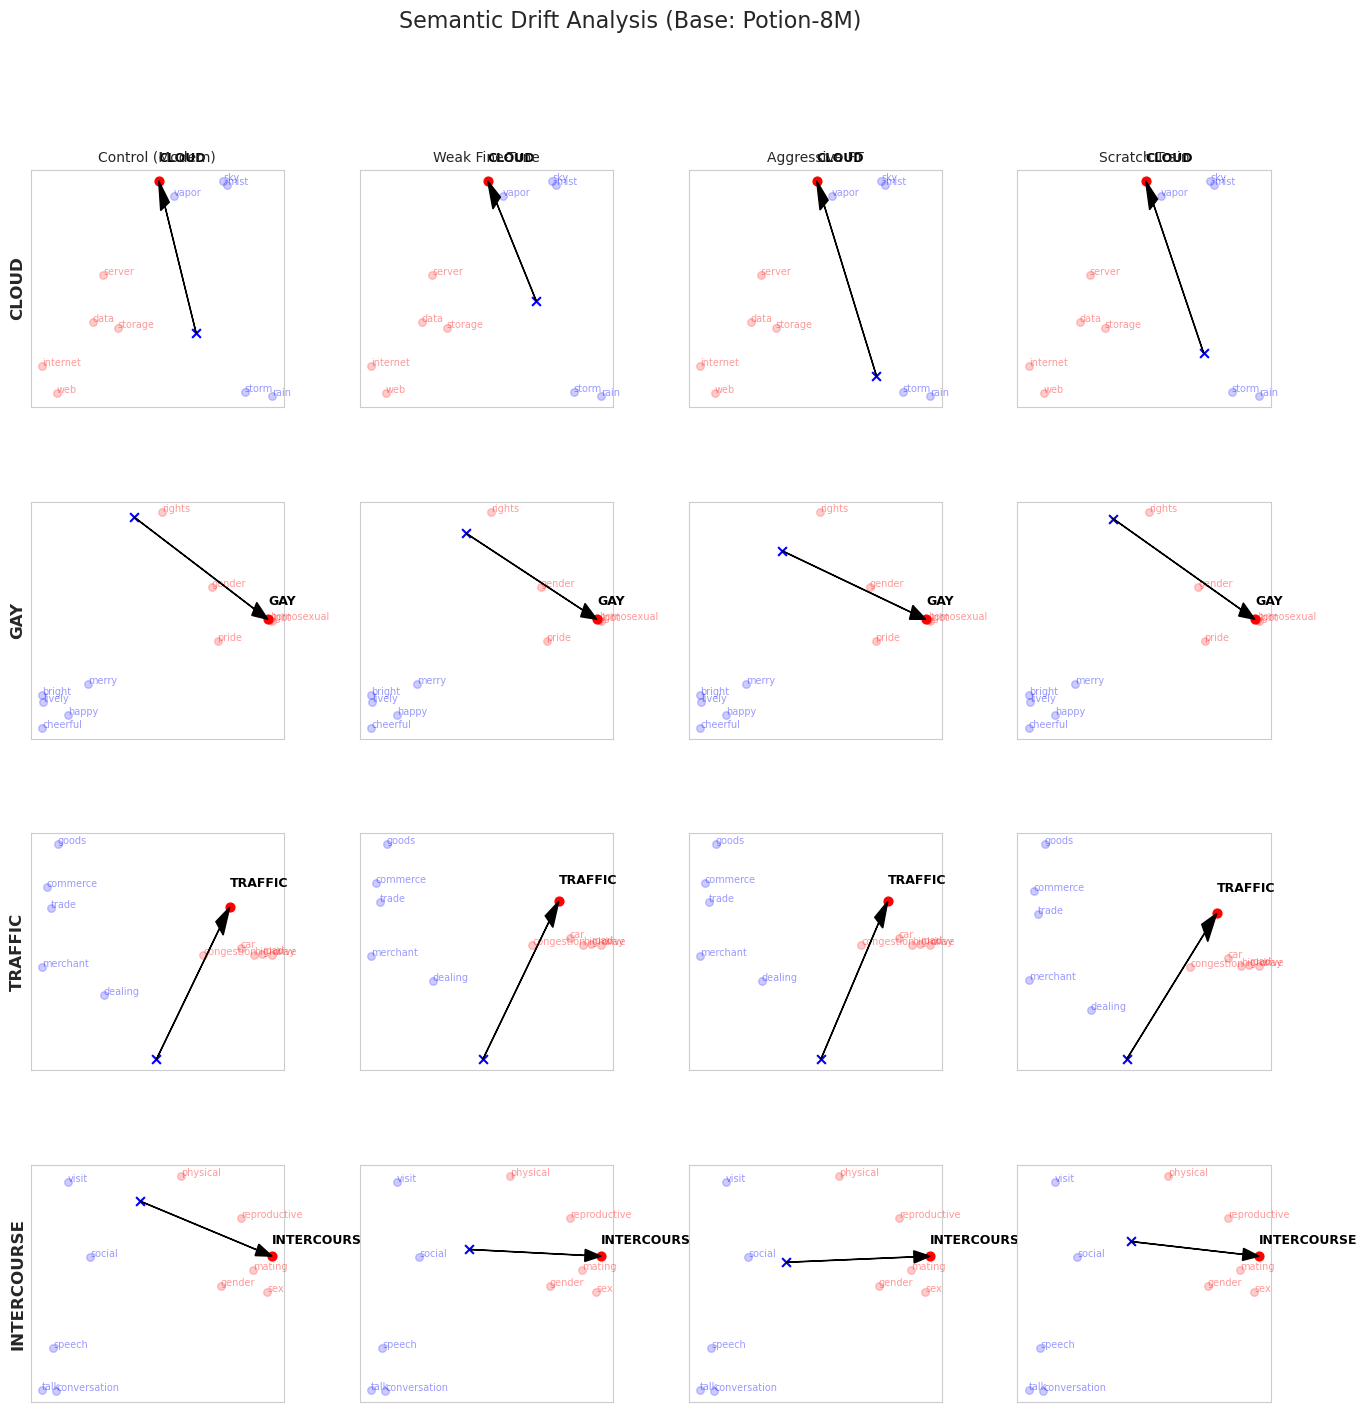

Generating dashboard for Base: MiniLM-L6...


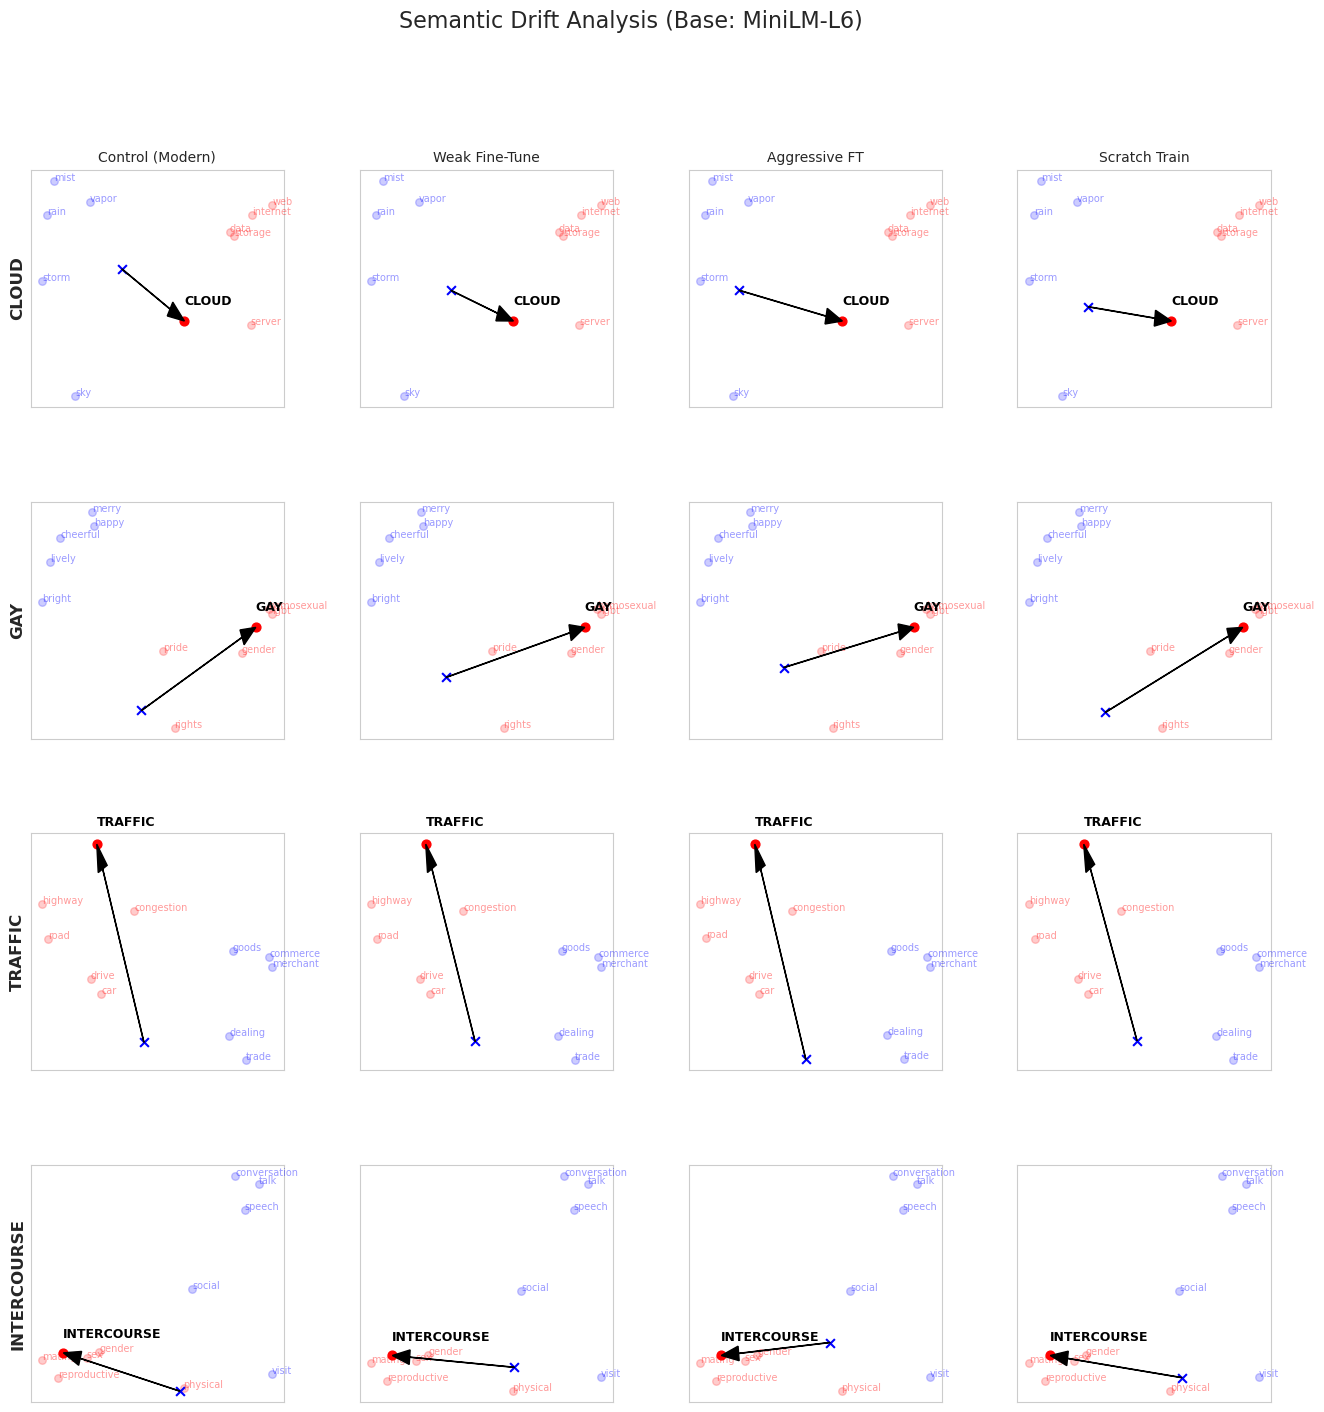

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel

# --- 1. CONFIGURATION ---

# Define the models
MODEL_PATHS = {
    "BASE_1": "minishlab/potion-base-8m",         # Modern Base 1
    "BASE_2": "models/all-MiniLM-L6-v2_static",           # Modern Base 2
    
    "VARIANTS": {
        "Control (Modern)": "models/all-MiniLM-L6-v2_static",         # Self-comparison (No drift expected)
        "Weak Fine-Tune":   "models/pg19_static_final",       # Your first attempt
        "Aggressive FT":    "models/pg19_aggressive_static_final",  # The one we just made
        "Scratch Train":    "models/pg19_scratch_static_final" # The 'ab initio' model
    }
}

# Words to analyze and their changing contexts
WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor"],
        "new": ["server", "data", "internet", "web", "storage"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing"],
        "new": ["car", "road", "highway", "congestion", "drive"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit"],
        "new": ["sex", "physical", "reproductive", "mating", "gender"]
    }
}

# Strict Anchors for Procrustes Alignment
STABLE_ANCHORS = [
    "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
    "summer", "winter", "north", "south", "east", "west", "hand", "foot",
    "head", "mother", "father", "son", "daughter", "man", "woman", "life",
    "death", "eat", "drink", "walk", "speak", "the", "and", "of", "to"
]

# --- 2. HELPER FUNCTIONS ---

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    """
    1. Aligns Variant -> Base using Strict Anchors.
    2. Fits PCA on Base (Modern Map).
    3. Returns projection function and rotation matrix.
    """
    # Align
    valid_anchors = [w for w in anchors 
                     if w in mod_base.tokenizer.get_vocab() 
                     and w in mod_variant.tokenizer.get_vocab()]
    
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    # Calculate Rotation R
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts (Defining the Map)
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec, title):
    """Draws a single semantic drift plot on a given matplotlib axis."""
    
    # Prepare Data
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    # Get Alignment & PCA
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except Exception as e:
        ax.text(0.5, 0.5, "Model/Vocab Error", ha='center')
        return

    # Helper for points
    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # 1. Plot Contexts (Base Model = Background Map)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c='blue', alpha=0.2, s=30)
        ax.text(p[0], p[1], w, color='blue', alpha=0.4, fontsize=7)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c='red', alpha=0.2, s=30)
        ax.text(p[0], p[1], w, color='red', alpha=0.4, fontsize=7)

    # 2. Plot Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.arrow(p_start[0], p_start[1], 
                 p_end[0]-p_start[0], p_end[1]-p_start[1], 
                 head_width=0.05, color='black', length_includes_head=True, zorder=5)
        
        # Markers
        ax.scatter([p_start[0]], [p_start[1]], c='blue', marker='x', s=40) # Start
        ax.scatter([p_end[0]], [p_end[1]], c='red', marker='o', s=40)     # End
        
        # Label only the target word to reduce clutter
        ax.text(p_end[0], p_end[1]+0.05, word.upper(), color='black', fontsize=9, fontweight='bold')
        
    except KeyError:
        ax.text(0, 0, "Word not in Vocab", ha='center')

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# --- 3. MAIN EXECUTION ---

def generate_dashboard(base_name, base_path):
    print(f"Generating dashboard for Base: {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print(f"Could not load {base_path}. Skipping.")
        return

    # Create 4x4 Grid
    # Rows: Words, Cols: Variants
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row_idx, word in enumerate(words):
        for col_idx, var_name in enumerate(variants):
            ax = axes[row_idx, col_idx]
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            
            # Load Variant (Lazy loading to save RAM)
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                
                # Title only on top row
                title = var_name if row_idx == 0 else ""
                # Word label on left column
                if col_idx == 0:
                    ax.set_ylabel(word.upper(), fontsize=12, fontweight='bold')
                
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word], title)
                
            except Exception as e:
                ax.text(0.5, 0.5, f"Load Error\n{var_name}", ha='center')

    fig.suptitle(f"Semantic Drift Analysis (Base: {base_name})", fontsize=16)
    plt.show()

# Run for Base 1
generate_dashboard("Potion-8M", MODEL_PATHS["BASE_1"])

# Run for Base 2 (Standard MiniLM)
generate_dashboard("MiniLM-L6", MODEL_PATHS["BASE_2"])

Generating High-Res Dashboard for Standard Base...


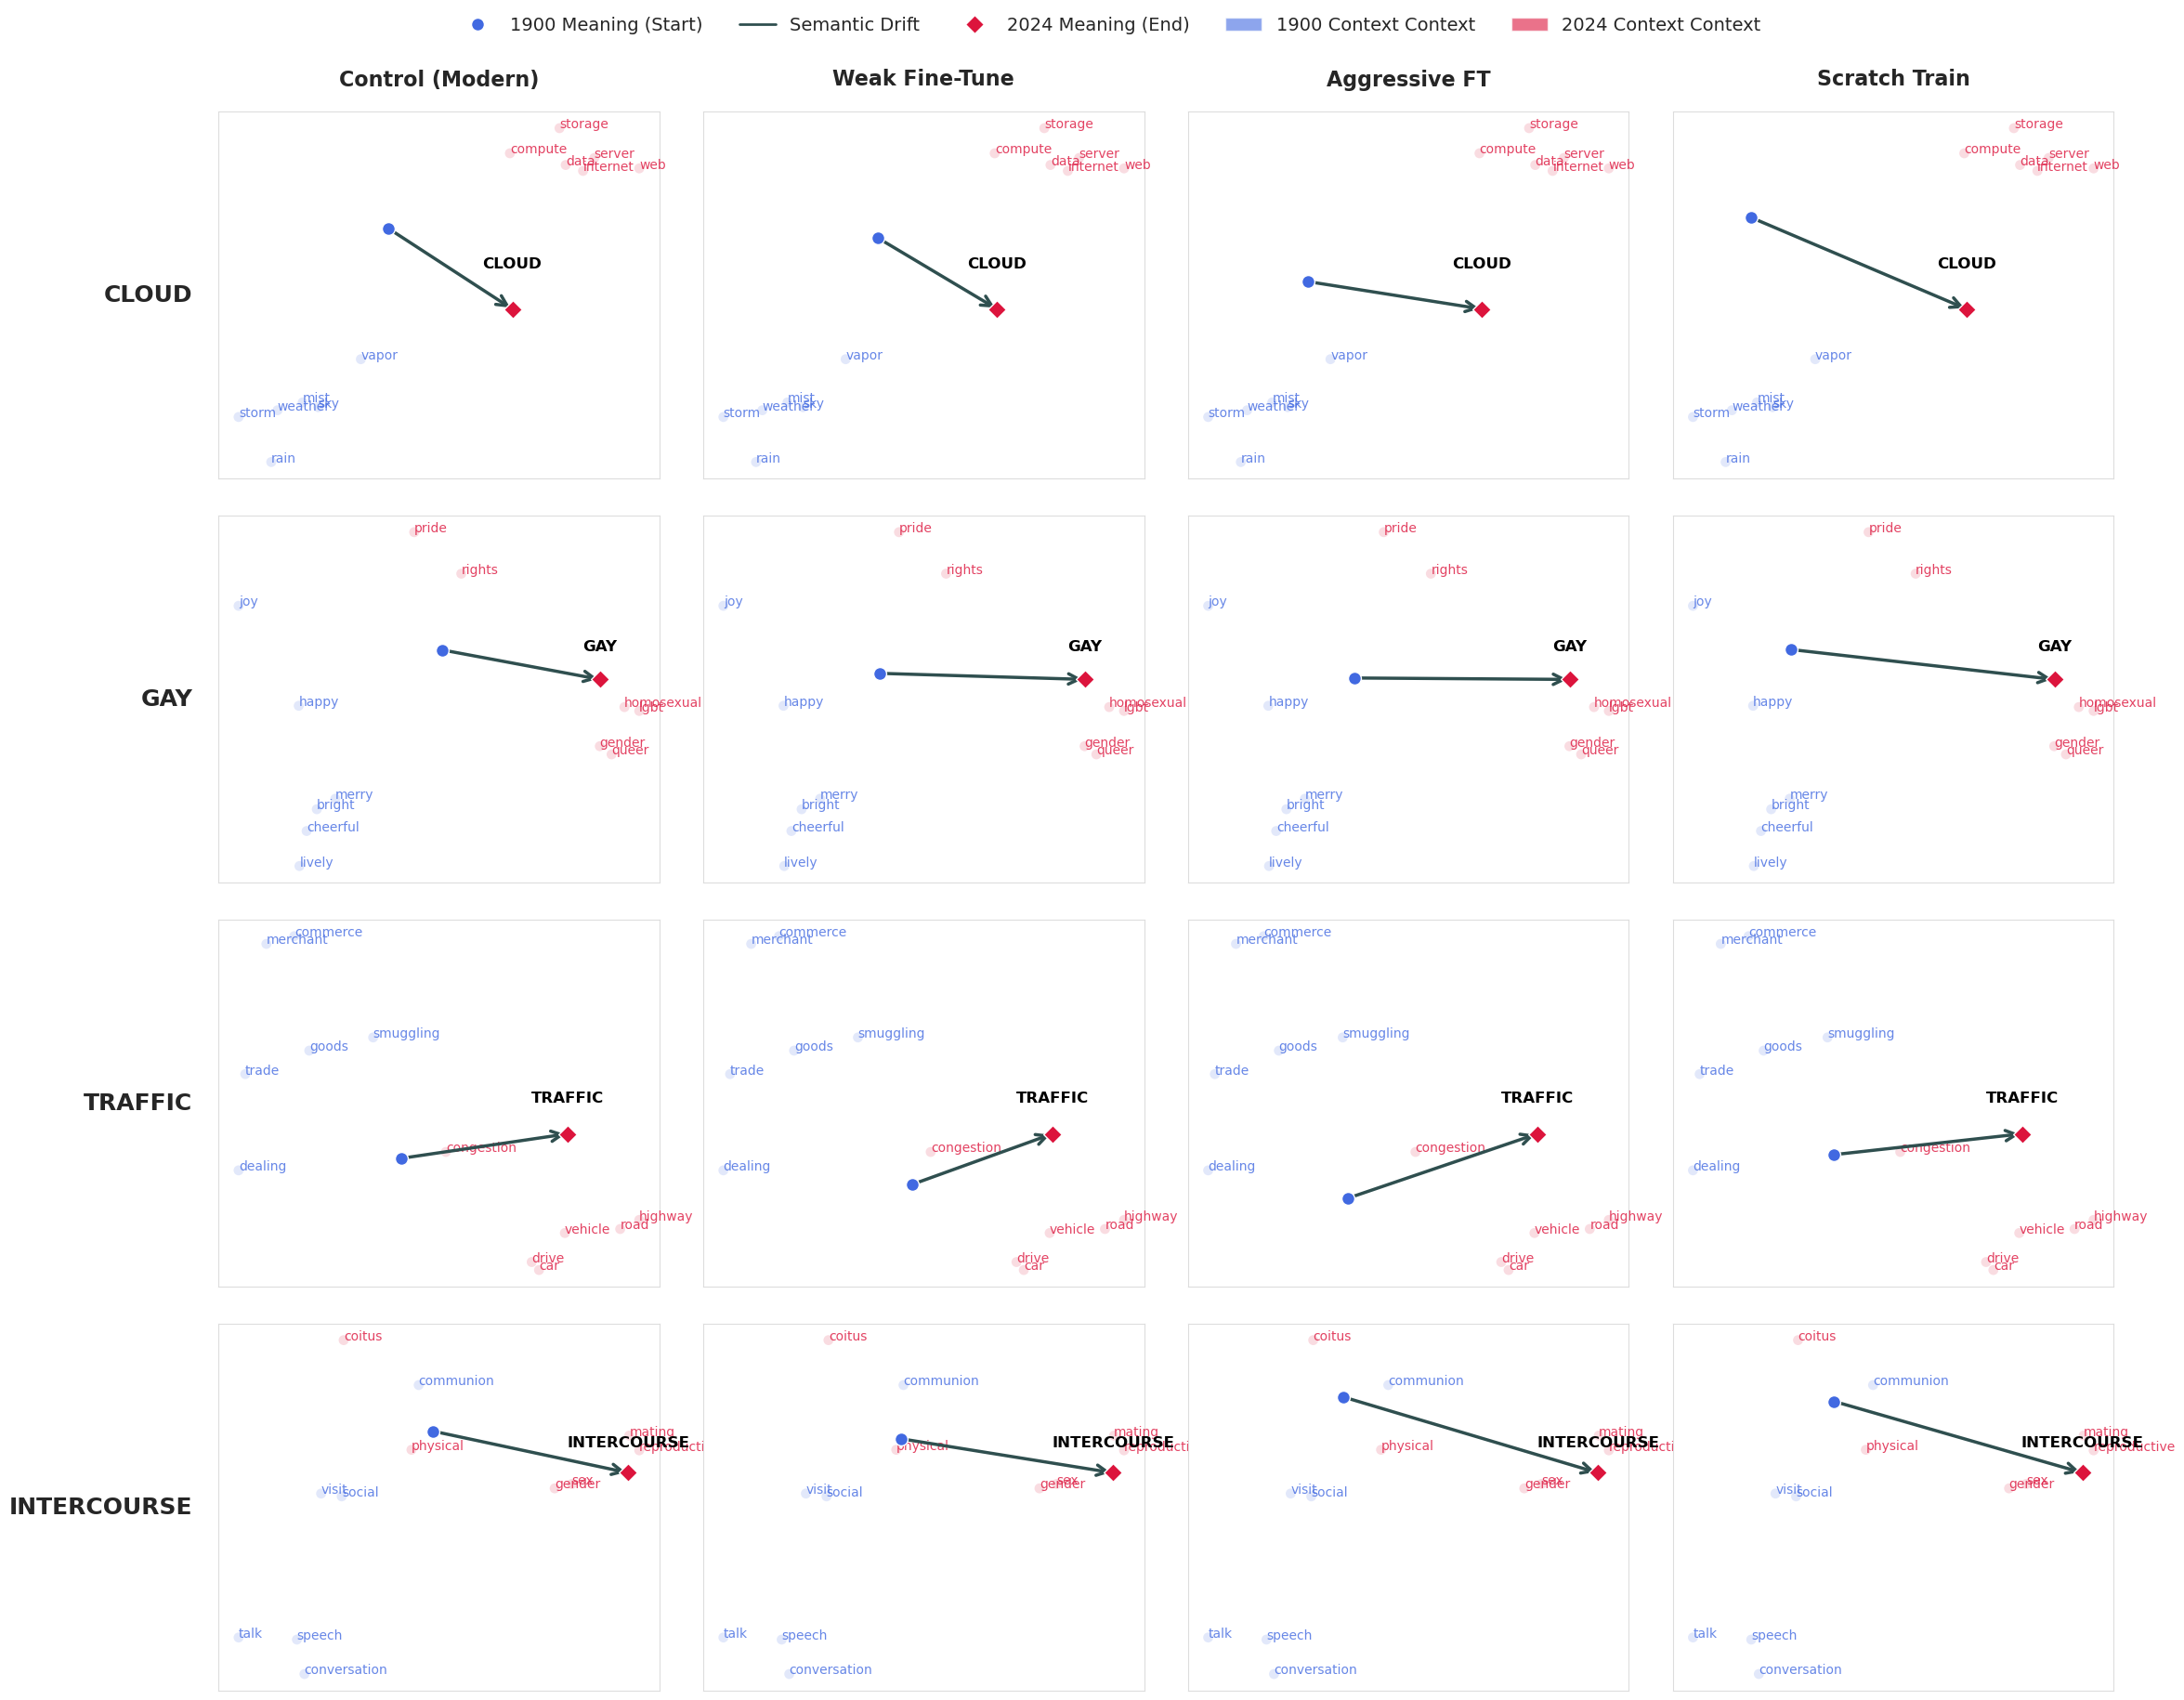

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. CONFIGURATION ---

MODEL_PATHS = {
    "BASE_1": "minishlab/potion-base-8m",         # Modern Base 1
    "BASE_2": "models/all-MiniLM-L6-v2_static",           # Modern Base 2
    
    "VARIANTS": {
        "Control (Modern)": "models/all-MiniLM-L6-v2_static",         # Self-comparison (No drift expected)
        "Weak Fine-Tune":   "models/pg19_static_final",       # Your first attempt
        "Aggressive FT":    "models/pg19_aggressive_static_final",  # The one we just made
        "Scratch Train":    "models/pg19_scratch_static_final" # The 'ab initio' model
    }
}

WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor", "weather"],
        "new": ["server", "data", "internet", "web", "storage", "compute"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively", "joy"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride", "queer"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing", "smuggling"],
        "new": ["car", "road", "highway", "congestion", "drive", "vehicle"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit", "communion"],
        "new": ["sex", "physical", "reproductive", "mating", "gender", "coitus"]
    }
}

# STABLE_ANCHORS = [
#     "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
#     "summer", "winter", "north", "south", "east", "west", "hand", "foot",
#     "head", "mother", "father", "son", "daughter", "man", "woman", "life"
# ]
STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]
# --- 2. PLOTTING ENGINE ---

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    # Align Variant -> Base
    valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_variant.tokenizer.get_vocab()]
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec):
    # Colors
    c_old = '#4169E1' # Royal Blue
    c_new = '#DC143C' # Crimson Red
    c_arr = '#2F4F4F' # Dark Slate Gray
    
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except:
        ax.text(0.5, 0.5, "Alignment Error", ha='center', fontsize=12, color='red')
        return

    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # 1. Plot Context Background (Faint)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_old, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_old, alpha=0.95, fontsize=10)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_new, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_new, alpha=0.95, fontsize=10)

    # 2. Plot The Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.annotate("", xy=p_end, xytext=p_start,
                    arrowprops=dict(arrowstyle="->", color=c_arr, lw=2.5, mutation_scale=20))
        
        # Draw Markers
        ax.scatter(p_start[0], p_start[1], c=c_old, marker='o', s=100, label='1900', edgecolors='white', zorder=10)
        ax.scatter(p_end[0], p_end[1], c=c_new, marker='D', s=100, label='2024', edgecolors='white', zorder=10)
        
        # Label Target
        ax.text(p_end[0], p_end[1]+0.08, word.upper(), color='black', fontsize=12, fontweight='bold', ha='center')
        
    except KeyError:
        ax.text(0.5, 0.5, "Missing Word", ha='center')

    # Cleanup Axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

def generate_dashboard(base_name, base_path):
    print(f"Generating High-Res Dashboard for {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print("Base model not found.")
        return

    # HUGE FIGURE SIZE for readability
    fig, axes = plt.subplots(4, 4, figsize=(24, 20), facecolor='white')
    
    # Add Legend Manually at the top
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='1900 Meaning (Start)', markersize=10),
        Line2D([0], [0], color='#2F4F4F', lw=2, label='Semantic Drift'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', label='2024 Meaning (End)', markersize=10),
        Patch(facecolor='#4169E1', alpha=0.6, label='1900 Context Context'),
        Patch(facecolor='#DC143C', alpha=0.6, label='2024 Context Context'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row, word in enumerate(words):
        for col, var_name in enumerate(variants):
            ax = axes[row, col]
            
            # Row Labels (Words)
            if col == 0:
                ax.set_ylabel(word.upper(), fontsize=18, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
            
            # Column Labels (Models)
            if row == 0:
                ax.set_title(var_name, fontsize=16, fontweight='bold', pad=20)
            
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word])
            except:
                ax.text(0.5, 0.5, "Load Error", ha='center')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

# Run
generate_dashboard("Standard Base", MODEL_PATHS["BASE_2"])

Generating High-Res Dashboard for Standard Base...


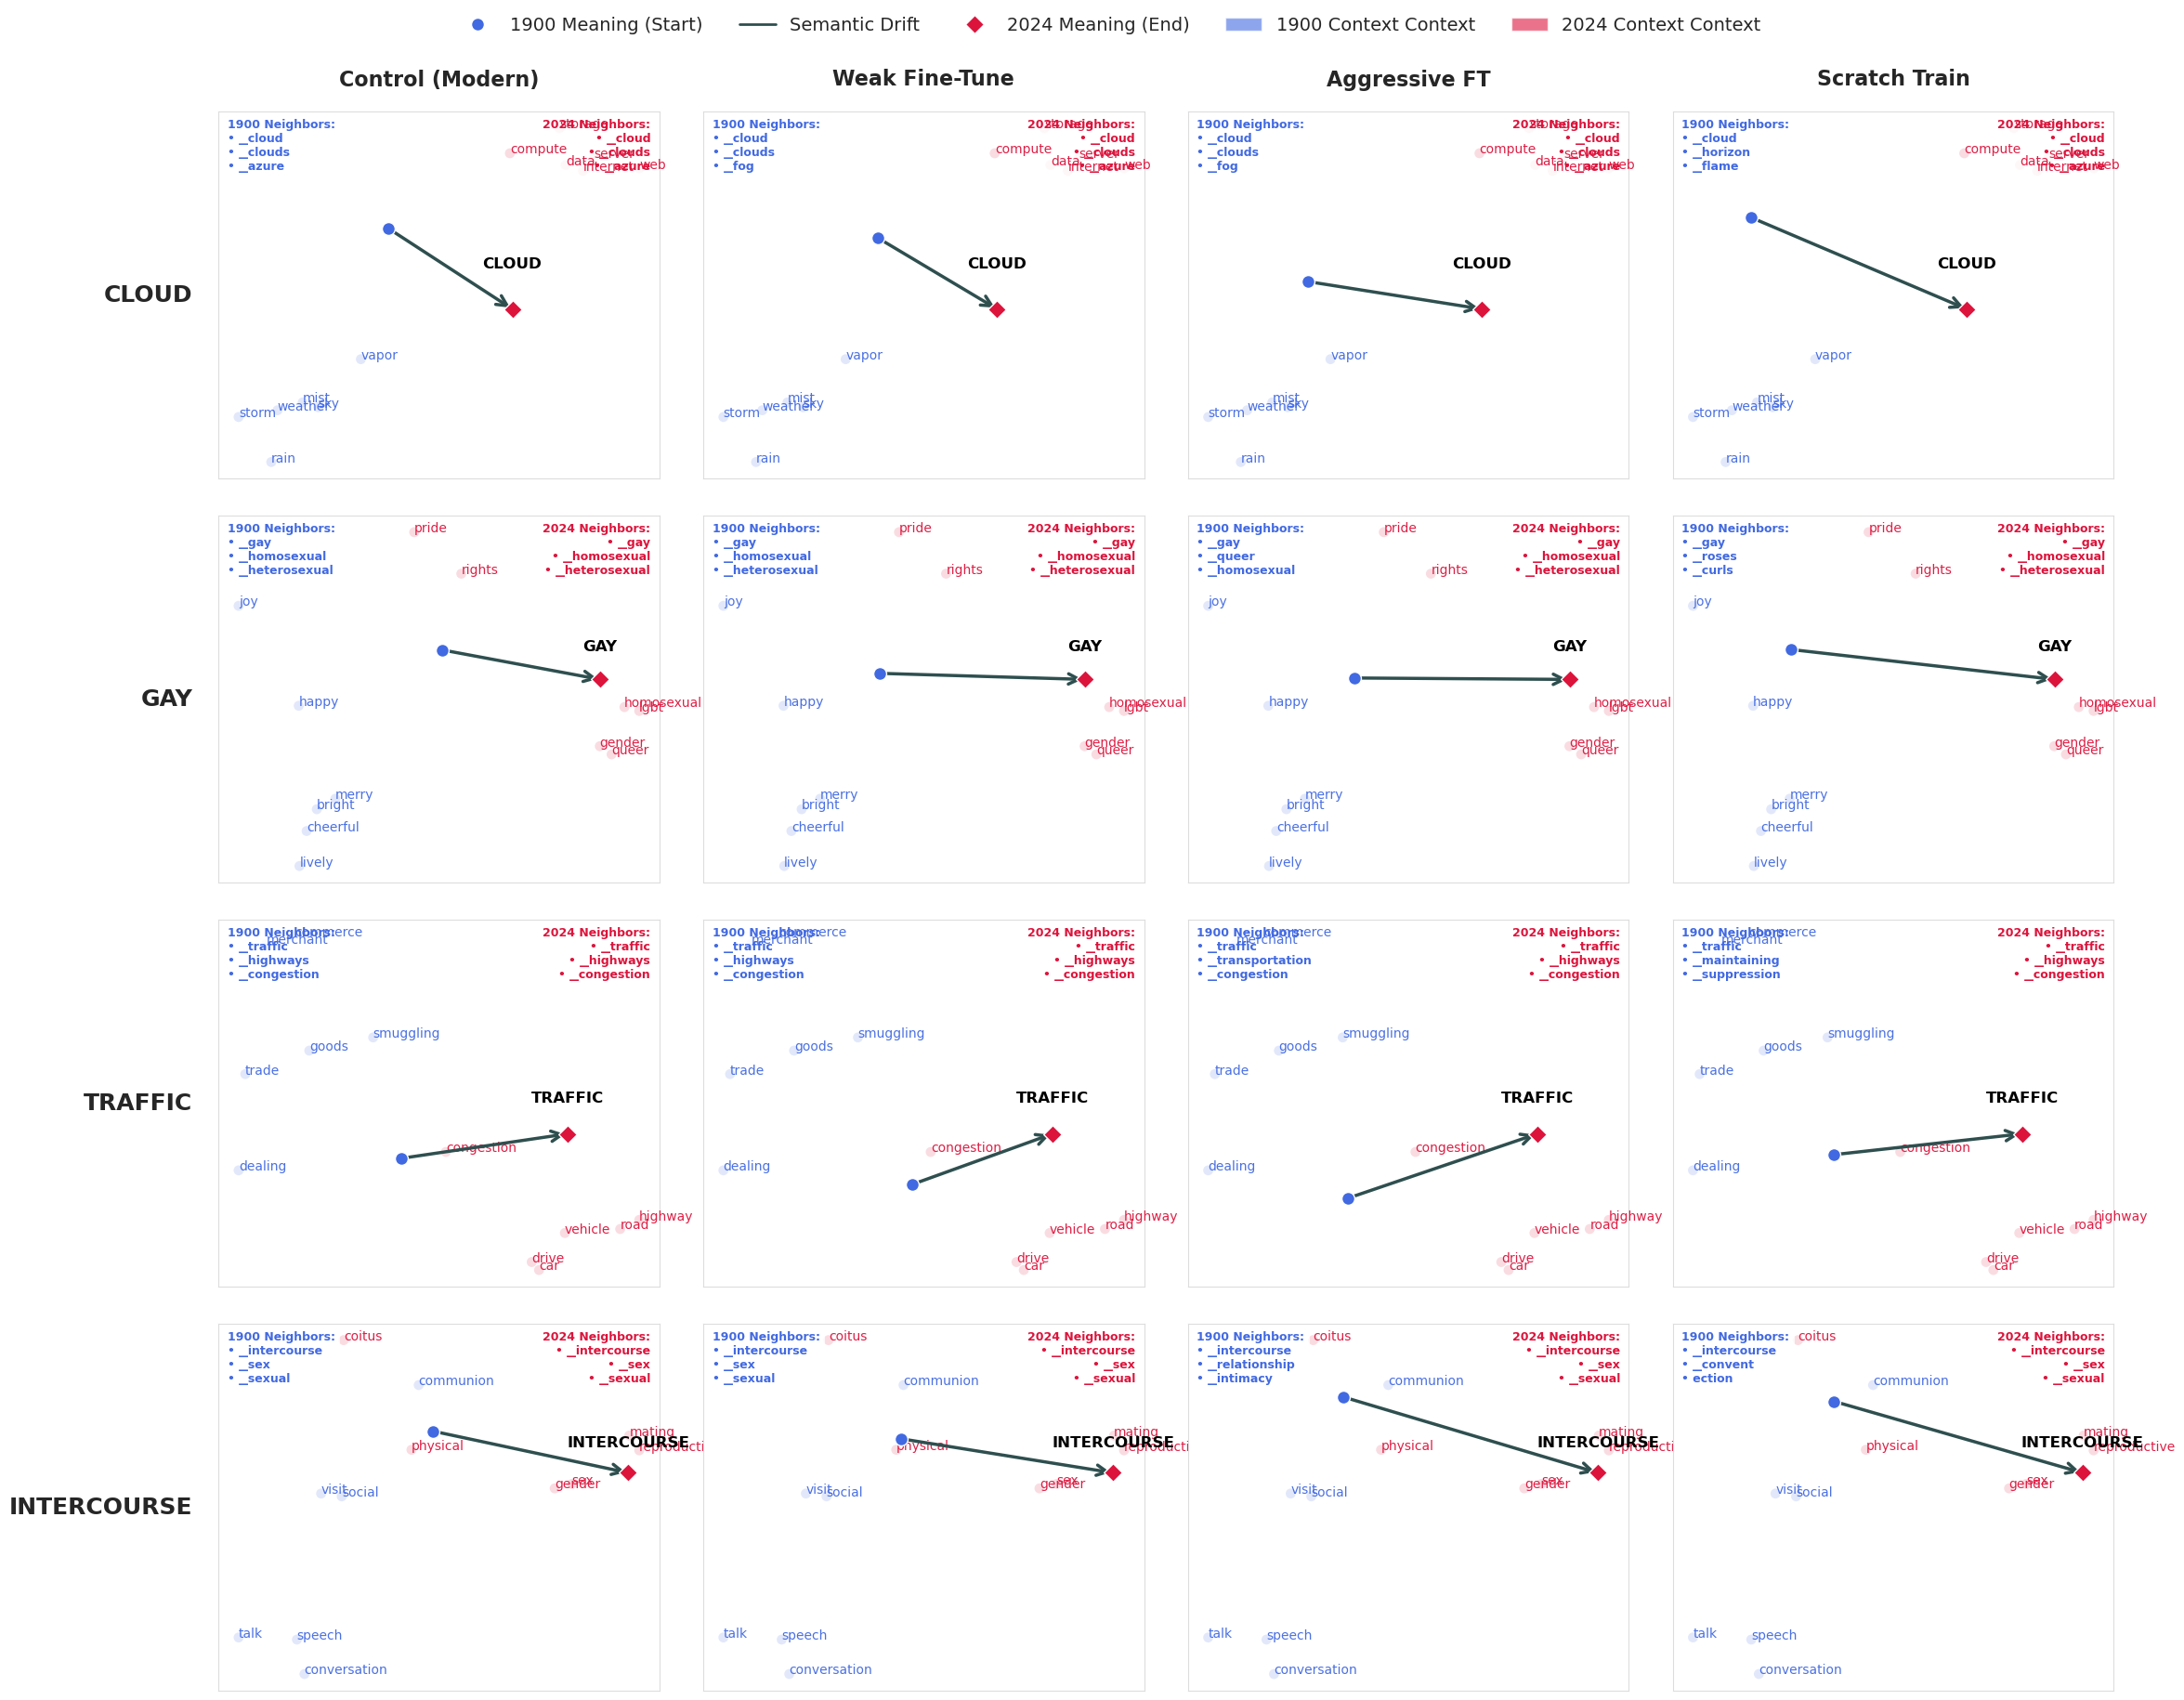

In [ ]:
WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor", "weather"],
        "new": ["server", "data", "internet", "web", "storage", "compute"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively", "joy"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride", "queer"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing", "smuggling"],
        "new": ["car", "road", "highway", "congestion", "drive", "vehicle"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit", "communion"],
        "new": ["sex", "physical", "reproductive", "mating", "gender", "coitus"]
    }
}

STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Grammar
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

# --- 2. HELPER FUNCTIONS ---

def get_nearest_neighbors(model, word, top_k=3):
    """
    Finds the top_k closest words in the model's vocabulary.
    Returns a formatted string like "1. word (0.12)\n2. word..."
    """
    try:
        # 1. Get vector
        vec = model.encode([word])
        
        # 2. Get vocab
        vocab_keys = list(model.tokenizer.get_vocab().keys())
        # Filter junk (too short, subwords) to get clean English words
        vocab = [w for w in vocab_keys if len(w) > 3 and not w.startswith("##")]
        
        # 3. Calculate distances
        all_vecs = model.encode(vocab)
        dists = cdist(vec, all_vecs, metric='cosine')[0]
        
        # 4. Sort
        # We skip index 0 because it's usually the word itself (distance 0)
        sorted_indices = np.argsort(dists)
        
        neighbors = []
        count = 0
        for idx in sorted_indices:
            cand = vocab[idx]
            if cand.lower() == word.lower(): continue # Skip self
            neighbors.append(cand)
            count += 1
            if count >= top_k: break
            
        return neighbors
    except:
        return ["N/A"]

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    # Align Variant -> Base
    valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_variant.tokenizer.get_vocab()]
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec):
    # Colors
    c_old = '#4169E1' # Royal Blue
    c_new = '#DC143C' # Crimson Red
    c_arr = '#2F4F4F' # Dark Slate Gray
    
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except:
        ax.text(0.5, 0.5, "Alignment Error", ha='center', fontsize=12, color='red')
        return

    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # --- PLOT NEIGHBORS TEXT ---
    # 1. Get Neighbors for 1900 (Variant Model)
    neigh_old = get_nearest_neighbors(mod_variant, word, top_k=3)
    text_old = f"1900 Neighbors:\n• " + "\n• ".join(neigh_old)
    
    # 2. Get Neighbors for 2024 (Base Model)
    neigh_new = get_nearest_neighbors(mod_base, word, top_k=3)
    text_new = f"2024 Neighbors:\n• " + "\n• ".join(neigh_new)
    
    # 3. Add Text Boxes (Top Left and Top Right)
    # Transform=ax.transAxes allows us to position relative to the box (0,0 to 1,1)
    ax.text(0.02, 0.98, text_old, transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', color=c_old, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
    ax.text(0.98, 0.98, text_new, transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='right', 
            color=c_new, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # --- PLOT SCATTER & ARROWS ---

    # 1. Plot Context Background (Faint)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_old, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_old, alpha=0.95, fontsize=10)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_new, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_new, alpha=0.95, fontsize=10)

    # 2. Plot The Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.annotate("", xy=p_end, xytext=p_start,
                    arrowprops=dict(arrowstyle="->", color=c_arr, lw=2.5, mutation_scale=20))
        
        # Draw Markers
        ax.scatter(p_start[0], p_start[1], c=c_old, marker='o', s=100, label='1900', edgecolors='white', zorder=10)
        ax.scatter(p_end[0], p_end[1], c=c_new, marker='D', s=100, label='2024', edgecolors='white', zorder=10)
        
        # Label Target
        ax.text(p_end[0], p_end[1]+0.08, word.upper(), color='black', fontsize=12, fontweight='bold', ha='center')
        
    except KeyError:
        ax.text(0.5, 0.5, "Missing Word", ha='center')

    # Cleanup Axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

def generate_dashboard(base_name, base_path):
    print(f"Generating High-Res Dashboard for {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print("Base model not found.")
        return

    # HUGE FIGURE SIZE for readability
    fig, axes = plt.subplots(4, 4, figsize=(24, 20), facecolor='white')
    
    # Add Legend Manually at the top
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='1900 Meaning (Start)', markersize=10),
        Line2D([0], [0], color='#2F4F4F', lw=2, label='Semantic Drift'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', label='2024 Meaning (End)', markersize=10),
        Patch(facecolor='#4169E1', alpha=0.6, label='1900 Context Context'),
        Patch(facecolor='#DC143C', alpha=0.6, label='2024 Context Context'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row, word in enumerate(words):
        for col, var_name in enumerate(variants):
            ax = axes[row, col]
            
            # Row Labels (Words)
            if col == 0:
                ax.set_ylabel(word.upper(), fontsize=18, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
            
            # Column Labels (Models)
            if row == 0:
                ax.set_title(var_name, fontsize=16, fontweight='bold', pad=20)
            
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word])
            except Exception as e:
                print(e)
                ax.text(0.5, 0.5, "Load Error", ha='center')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

# Run
generate_dashboard("Standard Base", MODEL_PATHS["BASE_2"])

Generating High-Res t-SNE Dashboard for Standard Base...


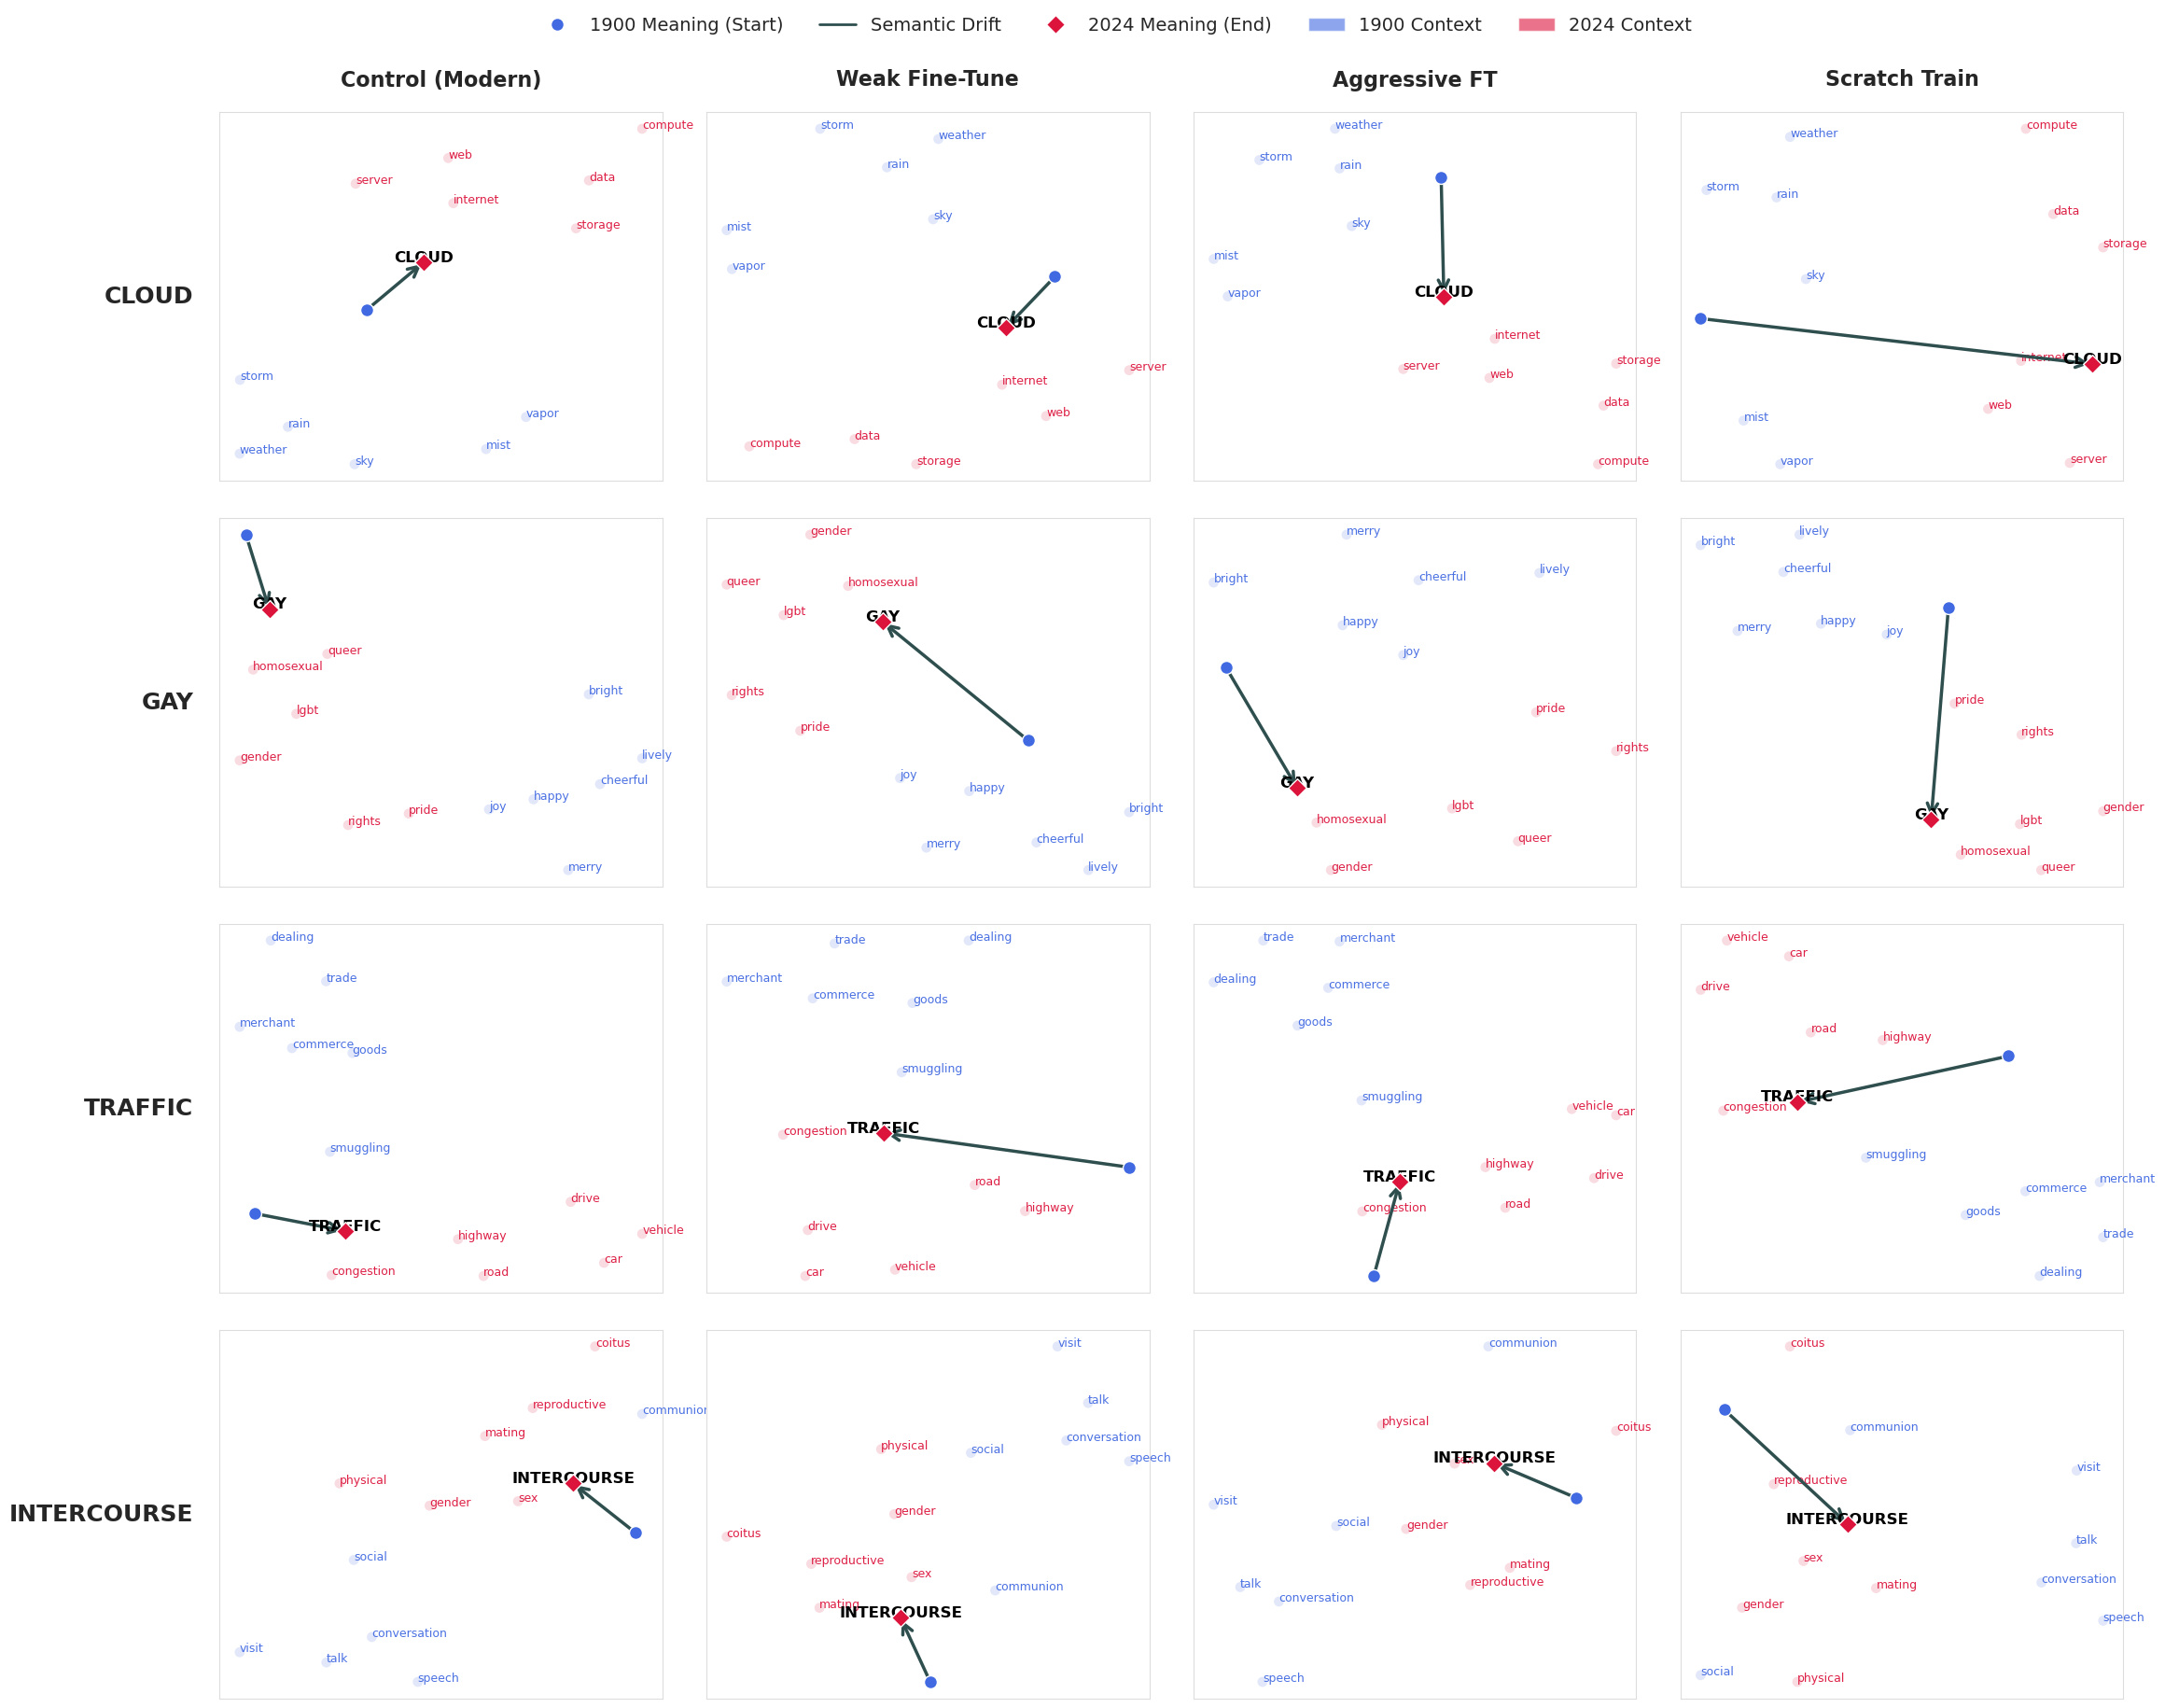

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def get_tsne_coordinates(mod_base, mod_variant, anchors, context_words, target_word):
    """
    Runs t-SNE on the combined set of vectors (Contexts + Anchors + Target_Start + Target_End).
    """
    # 1. Align Variant -> Base (Global Alignment)
    # We still need Procrustes to ensure the "1900 Vector" isn't in a totally random coordinate space
    # before we feed it to t-SNE alongside the modern vectors.
    valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_variant.tokenizer.get_vocab()]
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # 2. Build the dataset for t-SNE
    # We need: [Contexts (Modern)] + [Target (Modern)] + [Target (1900 Rotated)]
    
    # A. Context Vectors (Modern baseline)
    context_vecs = mod_base.encode(context_words)
    
    # B. Target Vector (Modern) - The "End" point
    target_mod_vec = mod_base.encode([target_word])
    
    # C. Target Vector (1900) - The "Start" point
    # We take the 1900 vector and rotate it to match the Modern orientation roughly
    target_old_vec_raw = mod_variant.encode([target_word])
    target_old_vec = target_old_vec_raw @ R
    
    # Combine everything into one matrix
    # Structure: [Contexts ... | Target_Modern | Target_Old]
    combined_matrix = np.vstack([context_vecs, target_mod_vec, target_old_vec])
    
    # 3. Run t-SNE
    # Perplexity must be low because we have very few points (approx 20)
    n_samples = combined_matrix.shape[0]
    perp = min(5, n_samples - 1) 
    
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate=200)
    coords = tsne.fit_transform(combined_matrix)
    
    # 4. Split coordinates back out
    # Contexts are everything except the last 2 rows
    coords_context = coords[:-2]
    coord_target_new = coords[-2] # 2nd to last
    coord_target_old = coords[-1] # Last one
    
    return coords_context, coord_target_new, coord_target_old

def plot_subplot(ax, mod_base, mod_variant, word, spec):
    # Colors
    c_old = '#4169E1' # Royal Blue
    c_new = '#DC143C' # Crimson Red
    c_arr = '#2F4F4F' # Dark Slate Gray
    
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    # We combine contexts for t-SNE input
    all_context_words = old_ctx + new_ctx
    
    try:
        # Run t-SNE calculation
        coords_ctx, p_end, p_start = get_tsne_coordinates(
            mod_base, mod_variant, STABLE_ANCHORS, all_context_words, word
        )
    except Exception as e:
        ax.text(0.5, 0.5, "Alignment Error", ha='center', fontsize=12, color='red')
        return

    # --- PLOT SCATTER & ARROWS ---

    # 1. Plot Context Background
    # We have to split the context coords back into Old list and New list
    len_old = len(old_ctx)
    coords_old_ctx = coords_ctx[:len_old]
    coords_new_ctx = coords_ctx[len_old:]
    
    # Plot Old Contexts (Blue)
    for i, w in enumerate(old_ctx):
        p = coords_old_ctx[i]
        ax.scatter(p[0], p[1], c=c_old, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_old, alpha=0.95, fontsize=9)
        
    # Plot New Contexts (Red)
    for i, w in enumerate(new_ctx):
        p = coords_new_ctx[i]
        ax.scatter(p[0], p[1], c=c_new, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_new, alpha=0.95, fontsize=9)

    # 2. Plot The Drift Arrow
    # Draw Arrow
    ax.annotate("", xy=p_end, xytext=p_start,
                arrowprops=dict(arrowstyle="->", color=c_arr, lw=2.5, mutation_scale=20))
    
    # Draw Markers
    ax.scatter(p_start[0], p_start[1], c=c_old, marker='o', s=100, label='1900', edgecolors='white', zorder=10)
    ax.scatter(p_end[0], p_end[1], c=c_new, marker='D', s=100, label='2024', edgecolors='white', zorder=10)
    
    # Label Target
    ax.text(p_end[0], p_end[1]+0.5, word.upper(), color='black', fontsize=12, fontweight='bold', ha='center')

    # Cleanup Axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

def generate_dashboard(base_name, base_path):
    print(f"Generating High-Res t-SNE Dashboard for {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print("Base model not found.")
        return

    # HUGE FIGURE SIZE
    fig, axes = plt.subplots(4, 4, figsize=(24, 20), facecolor='white')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='1900 Meaning (Start)', markersize=10),
        Line2D([0], [0], color='#2F4F4F', lw=2, label='Semantic Drift'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', label='2024 Meaning (End)', markersize=10),
        Patch(facecolor='#4169E1', alpha=0.6, label='1900 Context'),
        Patch(facecolor='#DC143C', alpha=0.6, label='2024 Context'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row, word in enumerate(words):
        for col, var_name in enumerate(variants):
            ax = axes[row, col]
            
            # Row Labels
            if col == 0:
                ax.set_ylabel(word.upper(), fontsize=18, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
            
            # Column Labels
            if row == 0:
                ax.set_title(var_name, fontsize=16, fontweight='bold', pad=20)
            
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word])
            except Exception as e:
                print(e)
                ax.text(0.5, 0.5, "Load Error", ha='center')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

# Run
generate_dashboard("Standard Base", MODEL_PATHS["BASE_2"])

Loading models into memory...
Computing Unified t-SNEs...


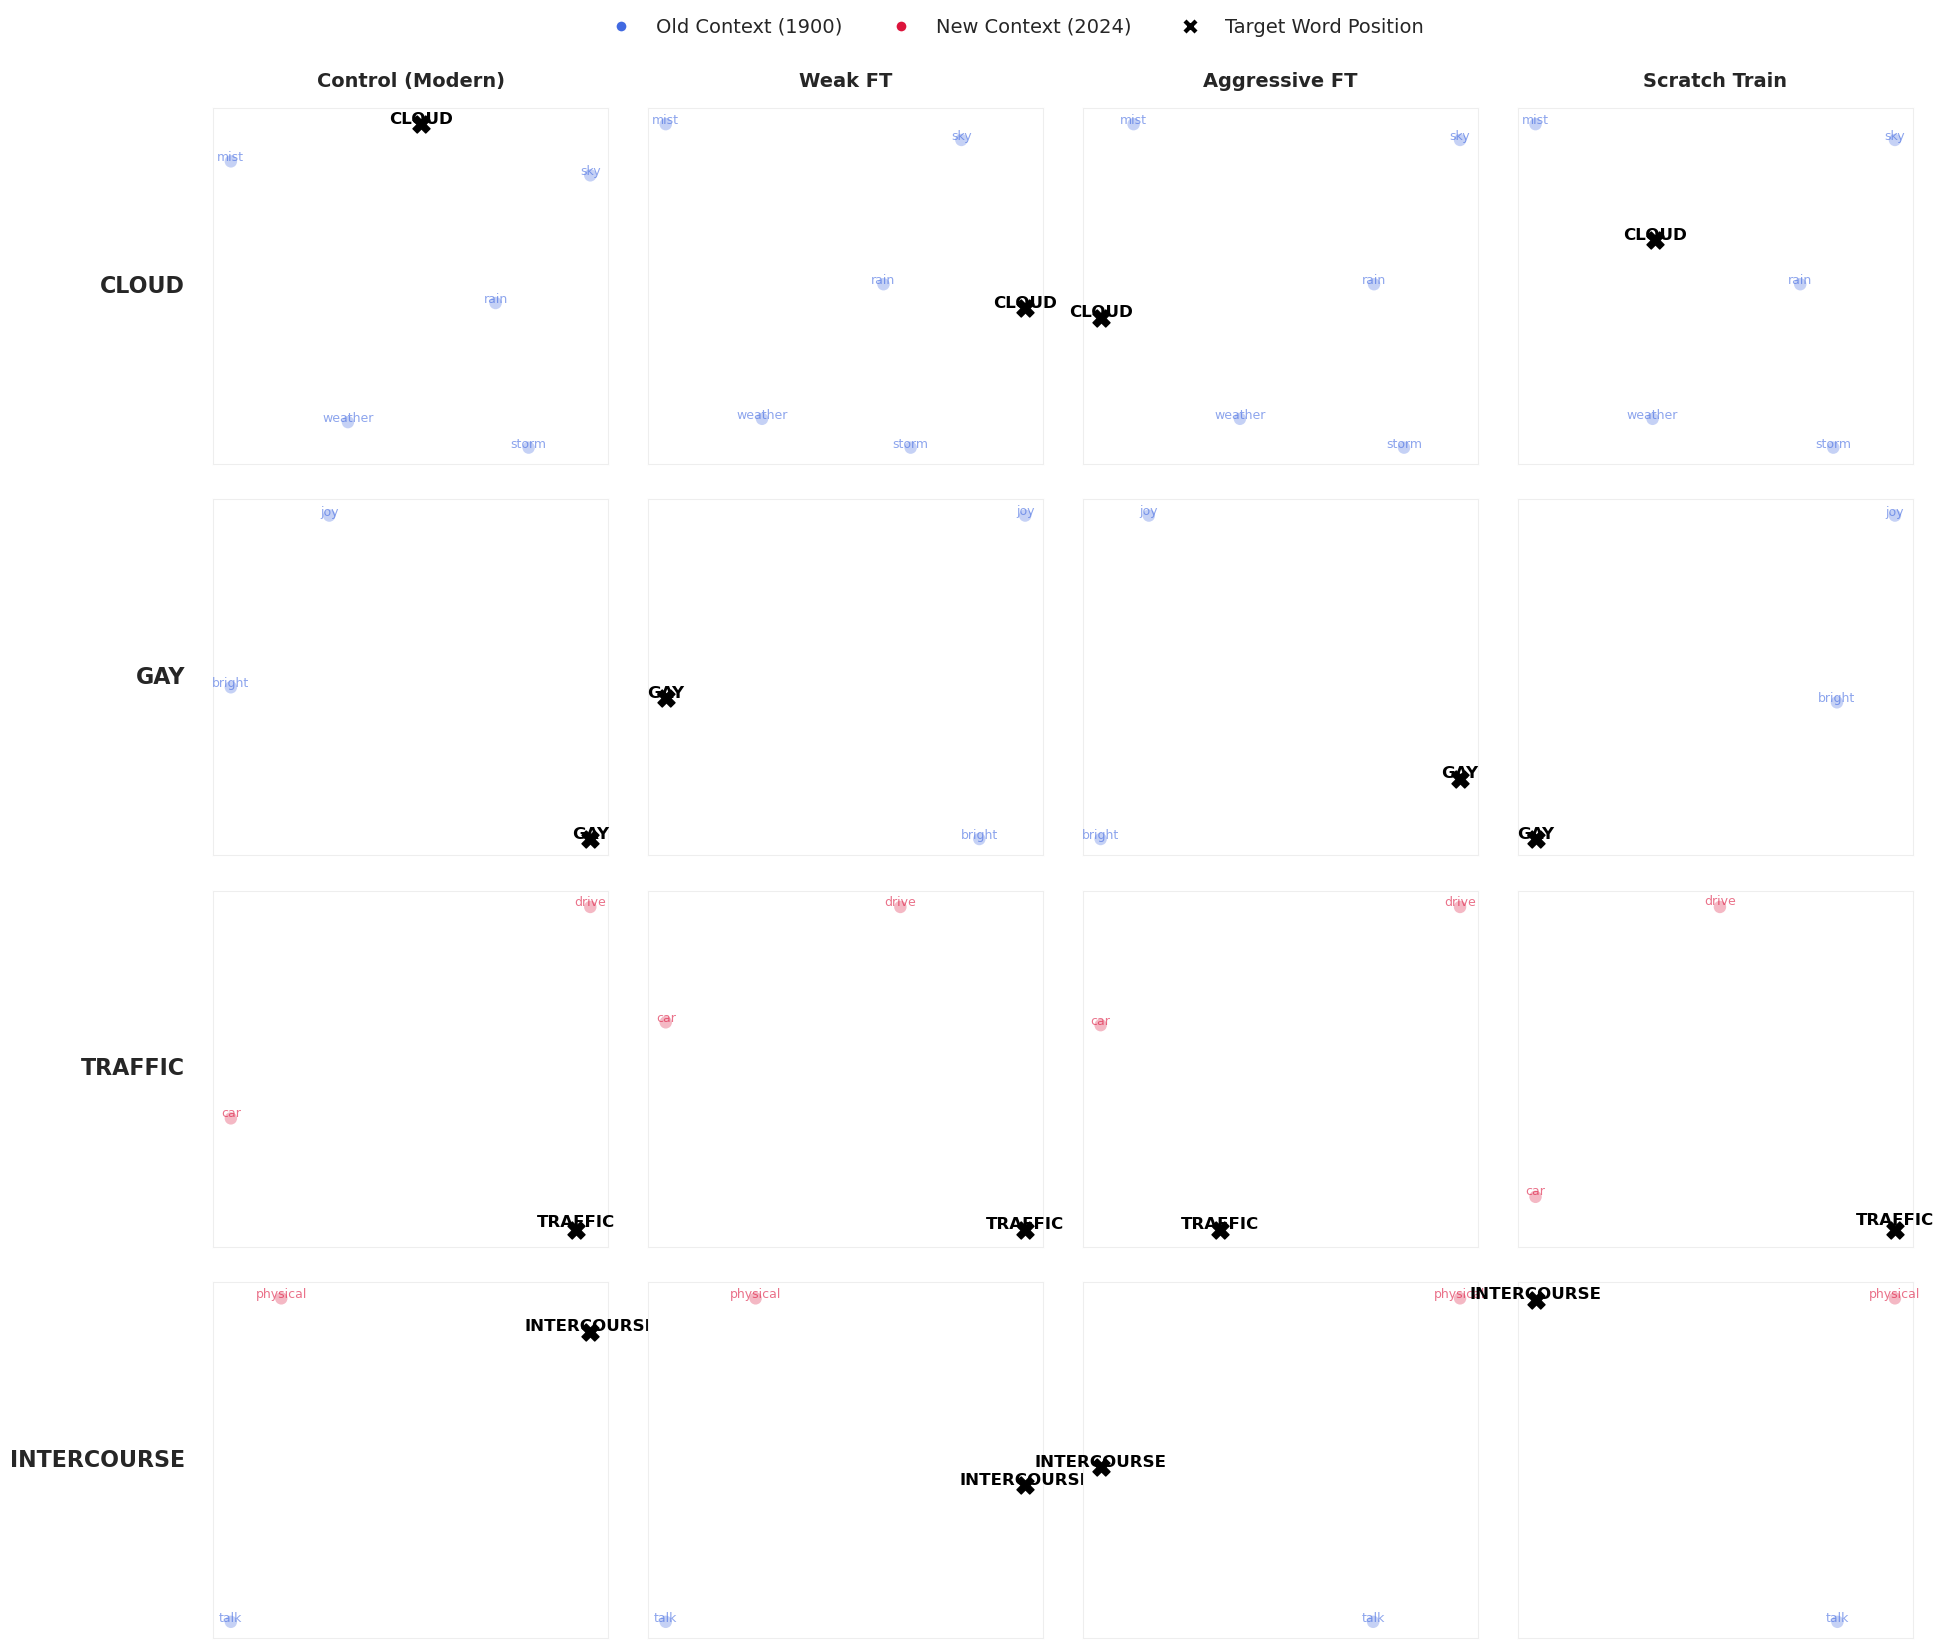

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

MODEL_PATHS = {
    "BASE": "models/all-MiniLM-L6-v2_static",  # Modern Base Model      
    "VARIANTS": {
        "Control (Modern)": "models/all-MiniLM-L6-v2_static",       
        "Weak FT":          "models/pg19_static_final",       
        "Aggressive FT":    "models/pg19_aggressive_static_final",  
        "Scratch Train":    "models/pg19_scratch_static_final" 
    }
}


def load_models():
    print("Loading models into memory...")
    models = {}
    # Load Base
    models["BASE"] = StaticModel.from_pretrained(MODEL_PATHS["BASE"])
    
    # Load Variants
    for name, path in MODEL_PATHS["VARIANTS"].items():
        try:
            models[name] = StaticModel.from_pretrained(path)
        except:
            print(f"Warning: Could not load {name} at {path}")
            models[name] = None
    return models

def compute_unified_tsne_for_word(word, spec, models, anchors):
    """
    Runs t-SNE ONCE for a specific word row, including all model variants.
    Returns a dictionary of coordinates for consistency.
    """
    mod_base = models["BASE"]
    
    # 1. Gather Fixed Contexts (Using Base Model Meanings)
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_context = old_ctx + new_ctx
    
    # Check vocab existence
    valid_ctx = [w for w in all_context if w in mod_base.tokenizer.get_vocab()]
    vecs_ctx = mod_base.encode(valid_ctx)
    
    # 2. Gather Target Words from ALL Variants (Aligned)
    variant_names = list(MODEL_PATHS["VARIANTS"].keys())
    vecs_targets = []
    
    for name in variant_names:
        mod_var = models[name]
        if mod_var is None:
            vecs_targets.append(np.zeros((1, vecs_ctx.shape[1]))) # Placeholder
            continue
            
        # Align Variant -> Base
        valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_var.tokenizer.get_vocab()]
        v_base_anc = mod_base.encode(valid_anchors)
        v_var_anc = mod_var.encode(valid_anchors)
        
        # Calculate Rotation
        R, _ = orthogonal_procrustes(v_var_anc, v_base_anc)
        
        # Get Aligned Target Vector
        # If word missing, use zero vector
        try:
            raw_vec = mod_var.encode([word])
            aligned_vec = raw_vec @ R
            vecs_targets.append(aligned_vec)
        except:
             vecs_targets.append(np.zeros((1, vecs_ctx.shape[1])))

    vecs_targets = np.vstack(vecs_targets)
    
    # 3. Stack Everything & Run t-SNE
    # [Contexts (Fixed) ... | Target_Control | Target_Weak | Target_Agg | Target_Scratch]
    full_matrix = np.vstack([vecs_ctx, vecs_targets])
    
    perp = min(30, len(full_matrix) - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate=200)
    coords = tsne.fit_transform(full_matrix)
    
    # 4. Unpack Coordinates
    res = {}
    
    # Context Coords (Same for everyone)
    n_ctx = len(valid_ctx)
    res["context_words"] = valid_ctx
    res["context_coords"] = coords[:n_ctx]
    
    # Target Coords (One per model)
    target_coords_all = coords[n_ctx:]
    for i, name in enumerate(variant_names):
        res[name] = target_coords_all[i]
        
    return res

# --- 3. PLOTTING ---

def generate_dashboard():
    models = load_models()
    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    # Setup Figure
    fig, axes = plt.subplots(4, 4, figsize=(20, 18), facecolor='white')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='Old Context (1900)', markersize=8),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#DC143C', label='New Context (2024)', markersize=8),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='black', label='Target Word Position', markersize=12),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    print("Computing Unified t-SNEs...")
    
    for row_idx, word in enumerate(words):
        # COMPUTE GLOBAL MAP FOR THIS WORD ROW
        # This ensures the background contexts are IDENTICAL across the row
        data = compute_unified_tsne_for_word(word, WORD_SPECS[word], models, STABLE_ANCHORS)
        
        ctx_words = data["context_words"]
        ctx_coords = data["context_coords"]
        
        # Identify which context is old vs new for coloring
        old_set = set(WORD_SPECS[word]["old"])
        
        for col_idx, var_name in enumerate(variants):
            ax = axes[row_idx, col_idx]
            
            # 1. Plot Fixed Background (Contexts)
            for i, w in enumerate(ctx_words):
                color = '#4169E1' if w in old_set else '#DC143C' # Blue if Old, Red if New
                x, y = ctx_coords[i]
                ax.scatter(x, y, c=color, alpha=0.3, s=80, edgecolors='none')
                ax.text(x, y+0.2, w, color=color, alpha=0.6, fontsize=9, ha='center')
            
            # 2. Plot Target Word for THIS Model
            tx, ty = data[var_name]
            
            # Draw big X for the target
            ax.scatter(tx, ty, c='black', marker='X', s=150, zorder=10)
            ax.text(tx, ty+0.5, word.upper(), color='black', fontweight='bold', fontsize=12, ha='center')
            
            # 3. Draw visual cues
            # Connect target to nearest context cluster center? (Optional, skipping for clarity)

            # Titles & Labels
            if row_idx == 0:
                ax.set_title(var_name, fontsize=14, fontweight='bold', pad=15)
            if col_idx == 0:
                ax.set_ylabel(word.upper(), fontsize=16, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
                
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor('#EEEEEE')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

generate_dashboard()